# Cavern Gamma Background Analysis for Kamioka Cryolab

To get the analysis, first all NaI data are compiled into one single ROOT file. The ROOT file has a special entry called *configID* and *runID* that denotes the geometrical configuration, background run v.s. calibration, and run ID in the case of background and calibration isotope in the case of calibration. This information is documented elsewhere and can also be found in the *inputs* TMacro under the ROOT file.

## Run Database

| Configuration | ConfigID | Run ID |
|---|---|---|
|Bottom|1|0-23|
|Top|6|0-45|
|West|3|0-68|
|South|4|0-44|
|East|2|0-44|
|North|5|0-68|
|Int|0|0-161|

For top, west, south, east, north, calibrations are done with Na-22, Co-57, Co-60, Ba-133, Cs-137.

# Analysis Pipeline

## Apply Cuts

After the cuts, one obtains a clear and accurate gamma energy spectra

## Calculate Livetime

Livetime is defined as time-duration that 
- the DAQ was able to record data but didn't record anything, or
- the DAQ recorded some physical event that we take into account in the gamma spectrum

Based on this definition:
- noises will be rejected, but does not change livetime
- non-gamma (neutron and alpha) events will be rejected but does not change livetime
- incomplete pulses and pile-up events are excluded, and livetime is reduced accordingly

## Perform Calibration

For runs denoted as calibration, fit the peaks of the energy spectra to get an energy-dependent ADC count-to-energy conversion factor and resolution.

## Convolve Monte-Carlo Spectra with Energy-Dependent Resolution Function and Fit to Data

The energy-dependent resolution function is applied to Monte-Carlo spectrum and perform a spectral fit to the histogram.

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from pyradet.util import set_plot_style
set_plot_style( figsize=(6,4), fontsize=11 )

channel = 0

# Open the ROOT file
filename = '../bin/test2.root'
file = uproot.open(filename)

In [2]:
# runinfo contains information relevant for the runs, including
# configuration ID, number of runs, calibrations applied (if any), total runtime (by wall clock), and livetime to be filled

runinfo = {
    'bottom':(1,23,None, 86452),
    'top':   (6,45,[22,57,60,133,137], 165699),
    'east':  (2,44,[22,57,60,133,137], 162100),
    'south': (4,44,[22,57,60,133,137], 162099),
    'west':  (3,68,[22,57,60,133,137], 248548),
    'north': (5,68,[22,57,60,133,137], 248551),
    'int':   (0,161,None, 583555)
}

In [3]:
# Extract necessary branches
tree = file["events"]

configID = tree["configID"].array(library="np")
runID = tree["runID"].array(library="np")
eventID = tree["eventID"].array(library="np")

timestamp = tree["timestamp"].array(library="np")

rawFAMR = tree["rawFAMR"].array(library="np")[:,channel]
rawMax = tree["rawMax"].array(library="np")[:,channel]
rawMin = tree["rawMin"].array(library="np")[:,channel]
bl_flag = tree["blFlag"].array(library="np")[:,channel]

pp_integral = tree["ppIntegral"].array(library="np")[:,channel]
pp_height = tree["ppHeight"].array(library="np")[:,channel]
pp_AWMT = tree["ppAWMT"].array(library="np")[:,channel]
pp_flag = tree["ppFlag"].array(library="np")[:,channel]

sp_integral = tree["spIntegral"].array(library="np")[:,channel]
sp_height = tree["spHeight"].array(library="np")[:,channel]
sp_AWMT = tree["spAWMT"].array(library="np")[:,channel]
sp_flag = tree["spFlag"].array(library="np")[:,channel]

# Developing Cuts

## Cuts for noise rejection

Noise primarily comes in three types:
- oscillatory noise
- transient noise with overshoot
- SPE-like single spikes

The oscillatory noise and SPE-like spikes can be effectively removed by imposing a cut range on FAMR (fraction above mid-range). The transient noise has an overshoot and therefore can be removed by imposing a maximum deviation from baseline or maximum ADC count in the data.

Based on inspection of ROOT file, the following set of cuts will be used:
- good baseline: blFlag < 3 (at least head or tail baseline has been found)
- FAMR > 0.7: already implemented when generating the ROOT file
- overshoot < 10: already implemented when generating the ROOT file
- rawMax < 4036: the maximum value should be less than this number to reject overshooting events further.
    - <div>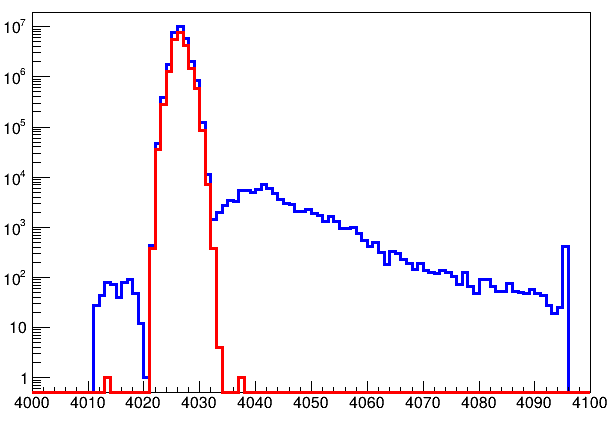</div>
- FAMR > 0.9 and FAMR < 0.99: it turns out normal events are within this range. When FAMR is too large, the event is a spe-like single spike.
    - <div>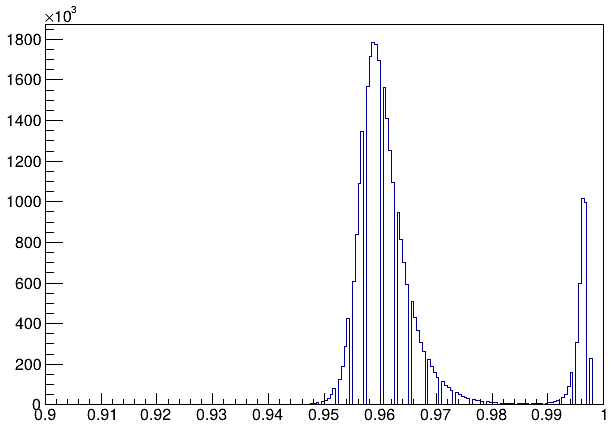</div>

In [4]:
mask_baseline = bl_flag < 3
    # cut that rejects noise
mask_FAMR = rawFAMR > 0.9
    # mask for cutting oscillation noise by FAMR
mask_overshoot = (rawMax > 4020) & (rawMax < 4036)
    # mask to remove positive overshoot and under baseline events
mask_spike = rawFAMR < 0.99
    # mask for removing spike events

## Cuts for physically valid but incomplete pulses

A physical pulse may have been recorded, but cannot be used in the analysis. This can be due to 1) the pulse exceeding ADC range, 2) the pulse was not recorded completely, i.e. the beginning of the pulse was already below threshold, or there's another pulse at the end of one event, 3) the pulse is a alpha or neutron event, in which it will not affect the gamma spectrum.

1. Reject saturated pulses (**no impact on livetime** since these are not due to natural K, U or Th)
    - rawMin > 500
        - <div>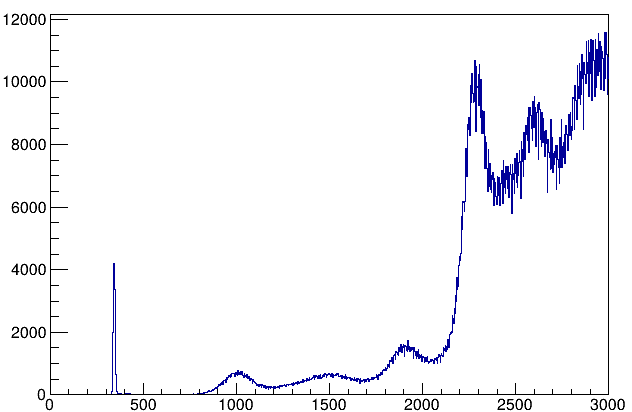</div>
2. Rejects pile-up and incomplete pulses (**impacts livetime**)
    - ppFlag and spFlag records the status of head and tail of each pulse found.
3. Remove alpha and neutron events (**no impact on livetime**)
    - with height-integral diagram or AWMT. The curve boundary will be developed in later sections of this notebook
        - <div>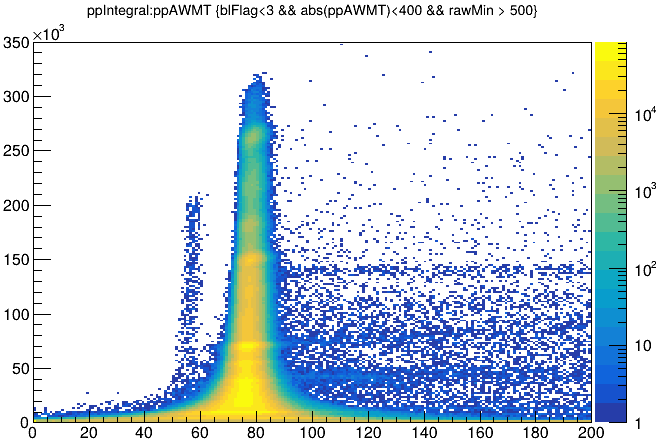</div>

In [5]:
mask_saturation = rawMin > 500
    # mask to remove saturation events

mask = mask_baseline & mask_FAMR & mask_overshoot & mask_spike & mask_saturation

### Cuts for alpha, neutron and pile-ups

This is done by plotting integral v.s. AWMT in the 2D histogram, and fit AWMT distribution of each integral value and take the 5-sigma boundaries. 5 sigma is selected by rough visual inspection.

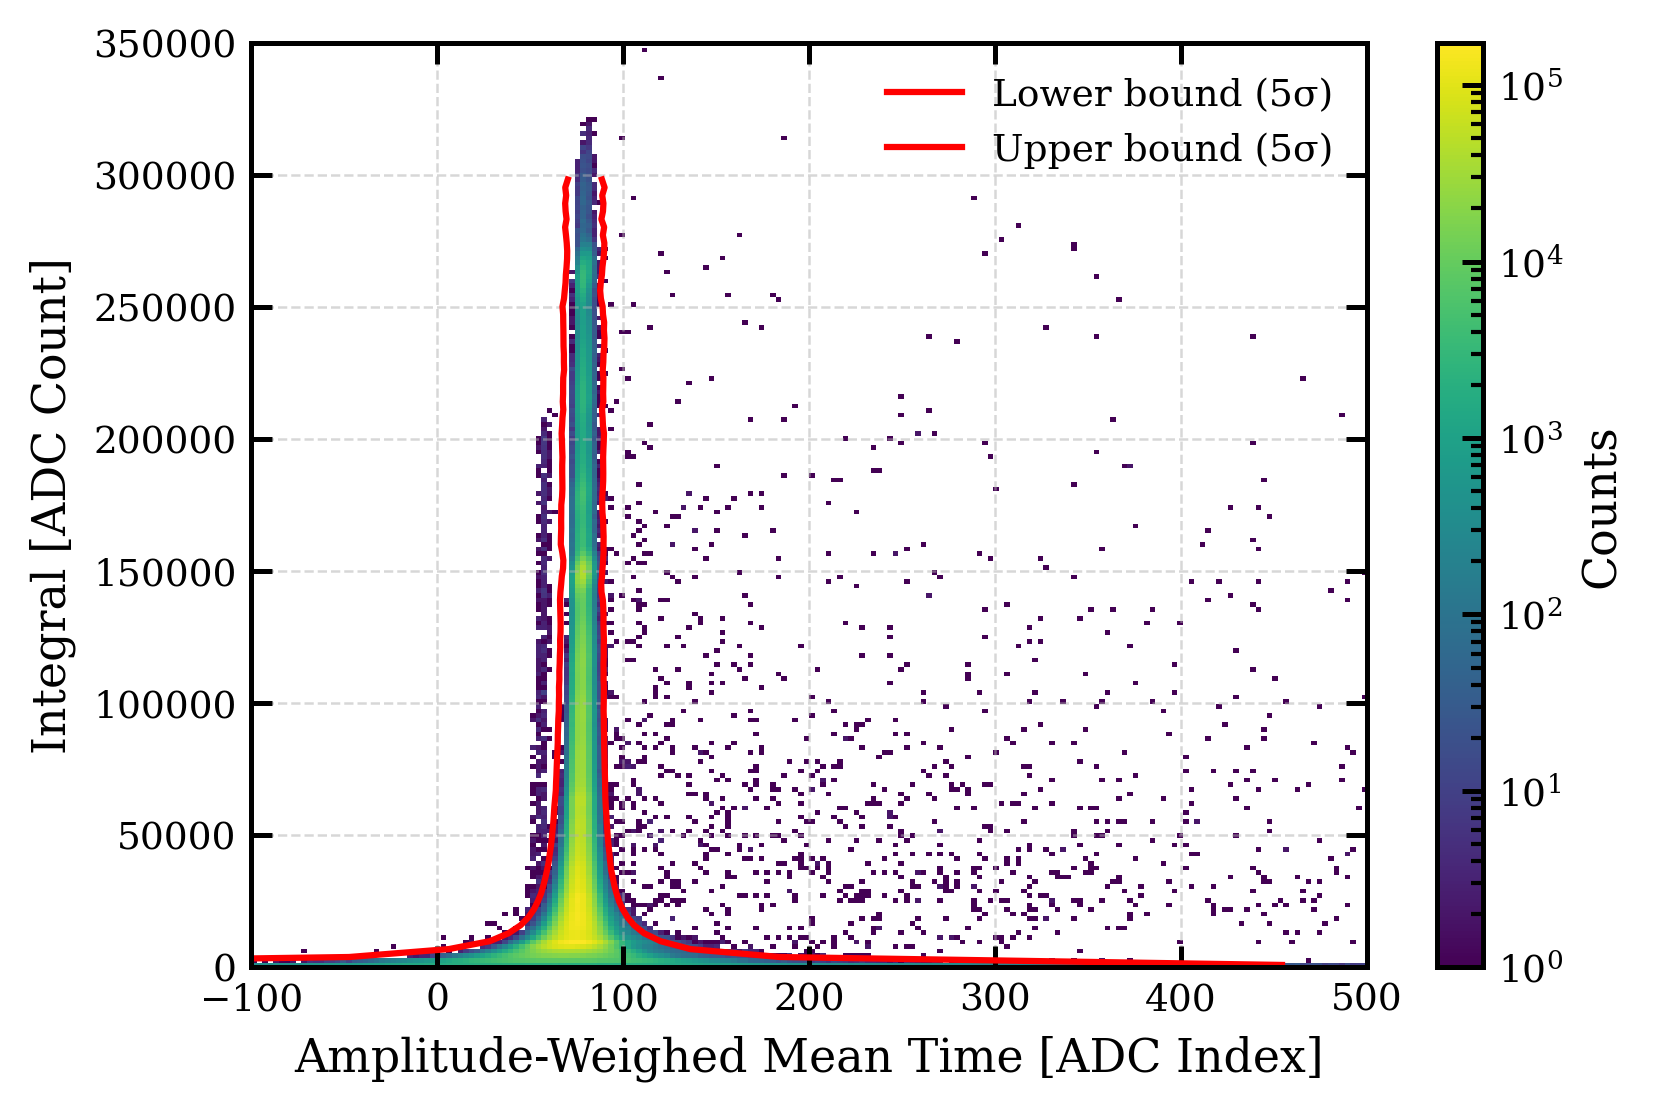

In [7]:
# Cuts for alpha, neutron and pile-ups
xlim = (-100,500)
ylim = (0,350000)
counts, xedges, yedges, img = plt.hist2d( pp_AWMT[mask & (configID<20)], pp_integral[mask & (configID<20)], bins=200, range=[xlim,ylim], norm=LogNorm() )
    # select only background runs, since lots of pile-ups in calibration

from scipy.optimize import curve_fit

# Collapse dimensions
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])

x_bounds_lower = []
x_bounds_upper = []
valid_y = []

# Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Loop over y bins (axis=1 in counts)
for j in range(len(y_centers)):
    profile = counts[:, j]  # x profile at fixed y

    if y_centers[j] > 300000:
        continue

    if np.sum(profile) < 10:  # skip low-stat bins
        continue

    try:
        p0 = [np.max(profile), x_centers[np.argmax(profile)], 1.0]
        popt, _ = curve_fit(gaussian, x_centers, profile, p0=p0)
        A, mu, sigma = popt

        N = 5  # e.g., 3σ bounds
        x_bounds_lower.append(mu - N * sigma)
        x_bounds_upper.append(mu + N * sigma)
        valid_y.append(y_centers[j])

    except RuntimeError:
        # fit failed
        continue

# Plot envelope over original histogram
#plt.figure(figsize=(8, 6))
#plt.pcolormesh(xedges, yedges, counts.T, cmap='viridis', shading='auto', norm=LogNorm() )

# functions that interpolates the AWMT bounts given integral
def intp_AWMT_lo( int_query ):
    awmt_lo_interp = np.interp( int_query, valid_y, x_bounds_lower, left=np.nan, right=np.nan)
    return awmt_lo_interp
    
def intp_AWMT_hi( int_query ):
    awmt_hi_interp = np.interp( int_query, valid_y, x_bounds_upper, left=np.nan, right=np.nan)
    return awmt_hi_interp

y_tmp = np.linspace( valid_y[0], valid_y[-1], 100)
awmt_lo = intp_AWMT_lo(y_tmp ) 
awmt_hi = intp_AWMT_hi(y_tmp )

plt.plot( awmt_lo, y_tmp, color='red', linestyle='-', label='Lower bound ({}σ)'.format(N) )
plt.plot( awmt_hi, y_tmp, color='red', linestyle='-', label='Upper bound ({}σ)'.format(N) )

plt.xlabel("Amplitude-Weighed Mean Time [ADC Index]")
plt.ylabel("Integral [ADC Count]")
plt.legend()
plt.grid(True)
plt.colorbar(label="Counts")
plt.xlim( xlim )
plt.show()

In [8]:
psd_cut_threshold = (1000,300000)

mask_psd0 = (pp_integral<psd_cut_threshold[0]) 
mask_psd1 = (pp_integral>psd_cut_threshold[1]) & (pp_AWMT<100)
mask_psd2 = (pp_integral>psd_cut_threshold[0]) & (pp_integral<psd_cut_threshold[1]) & (pp_AWMT>intp_AWMT_lo(pp_integral)) & (pp_AWMT<intp_AWMT_hi(pp_integral))

mask &= mask_psd0 | mask_psd1 | mask_psd2

Text(0, 0.5, 'Integral [ADC Count]')

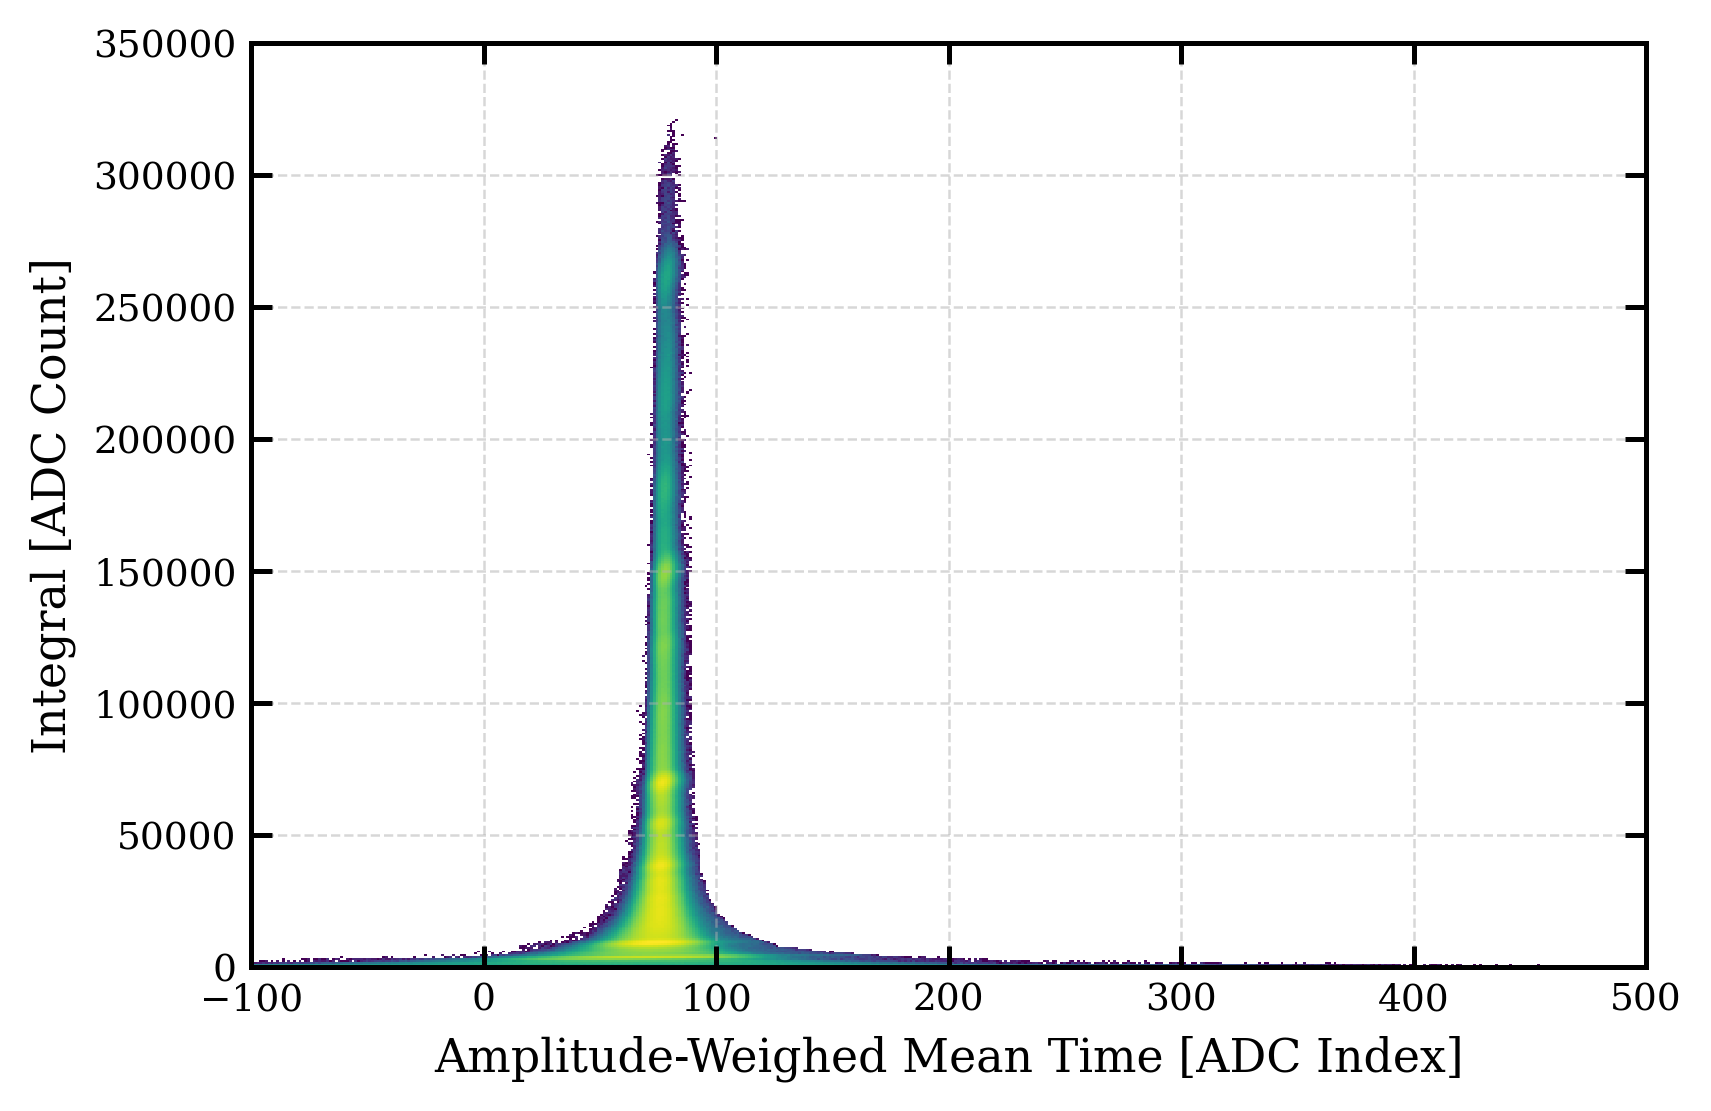

In [9]:
plt.hist2d( pp_AWMT[mask], pp_integral[mask], bins=500, range=(xlim,ylim), norm=LogNorm() );
plt.xlabel("Amplitude-Weighed Mean Time [ADC Index]")
plt.ylabel("Integral [ADC Count]")

* * *
# Livetime Calculation

In [10]:
# variable to store final livetime of each configuration
livetime = {}

for key,val in runinfo.items():
    
    con = val[0]
    nrun = val[1]
    runtime = val[3]

    mask_config = (runID<=nrun) & (configID==con)
    ntotal = len( eventID[ mask_config ] )
    mask_excl = mask & (pp_flag>0) & mask_config
    
    mask_pileup1 = (pp_integral>psd_cut_threshold[1]) & (pp_AWMT<100)
    mask_pileup2 = (pp_integral>psd_cut_threshold[0]) & (pp_integral<psd_cut_threshold[1]) & (pp_AWMT>intp_AWMT_hi(pp_integral))
    mask_pileup = mask_pileup1 | mask_pileup2

    mask_deadtime = (mask_excl | mask_pileup) & mask_config
    nexcl = len( eventID[mask_deadtime] )

    # set livetime in runinfo
    livetime[key] = val[3] * (ntotal-nexcl)/ntotal
    print( key, f'total = {ntotal}, excluded = {nexcl}, livetime = {livetime[key]} s')
    

bottom total = 4180161, excluded = 1671, livetime = 86417.44121338867 s
top total = 3896758, excluded = 2105, livetime = 165609.49061938154 s
east total = 1655126, excluded = 1676, livetime = 161935.8556387852 s
south total = 2260152, excluded = 1632, livetime = 161981.952311172 s
west total = 3547553, excluded = 2547, livetime = 248369.5525586228 s
north total = 3112658, excluded = 2321, livetime = 248365.66422877167 s
int total = 1473173, excluded = 5205, livetime = 581493.189353864 s


***
# Calibration

## Define some useful functions

In [11]:
from scipy.optimize import curve_fit

# Define fitting function: Gaussian + quadratic background
def gamma_peak(x, A, mu, sigma, a0, a1):
    gaussian = A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    background = a0 + a1 * x
    return gaussian + background

def fit_gamma(bin_centers, counts, xmin, xmax):
    fit_mask = (bin_centers >= xmin) & (bin_centers <= xmax)
    x_fit = bin_centers[fit_mask]
    y_fit = counts[fit_mask]

    p0 = [np.max(y_fit) - np.min(y_fit), x_fit[np.argmax(y_fit)], (x_fit[-1]-x_fit[0])/2, np.min(y_fit), (y_fit[-1]-y_fit[0])/(x_fit[-1]-x_fit[0]) ]
    bounds = ([0,xmin,0.1,0,-np.inf],[10*np.max(y_fit),xmax,np.inf,np.max(y_fit),np.inf])
    popt, pcov = curve_fit(gamma_peak, x_fit, y_fit, p0=p0, bounds=bounds)

    x_fit = np.linspace(xmin,xmax,100)
    y_fit_curve = gamma_peak(x_fit, *popt)
    
    return popt, x_fit, y_fit_curve

In [12]:
# Define a consistant good binning strategy to be used next
#
nbins = 1000
bins = np.linspace(0, 3e5, nbins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# dictionary used to store calibration information (peak position in ADC count and sigma/FWHM)
#
calibration = {}
for key in runinfo.keys():
    calibration[key] = []

## Cs-137: 661.7 keV

<Figure size 2400x1800 with 0 Axes>

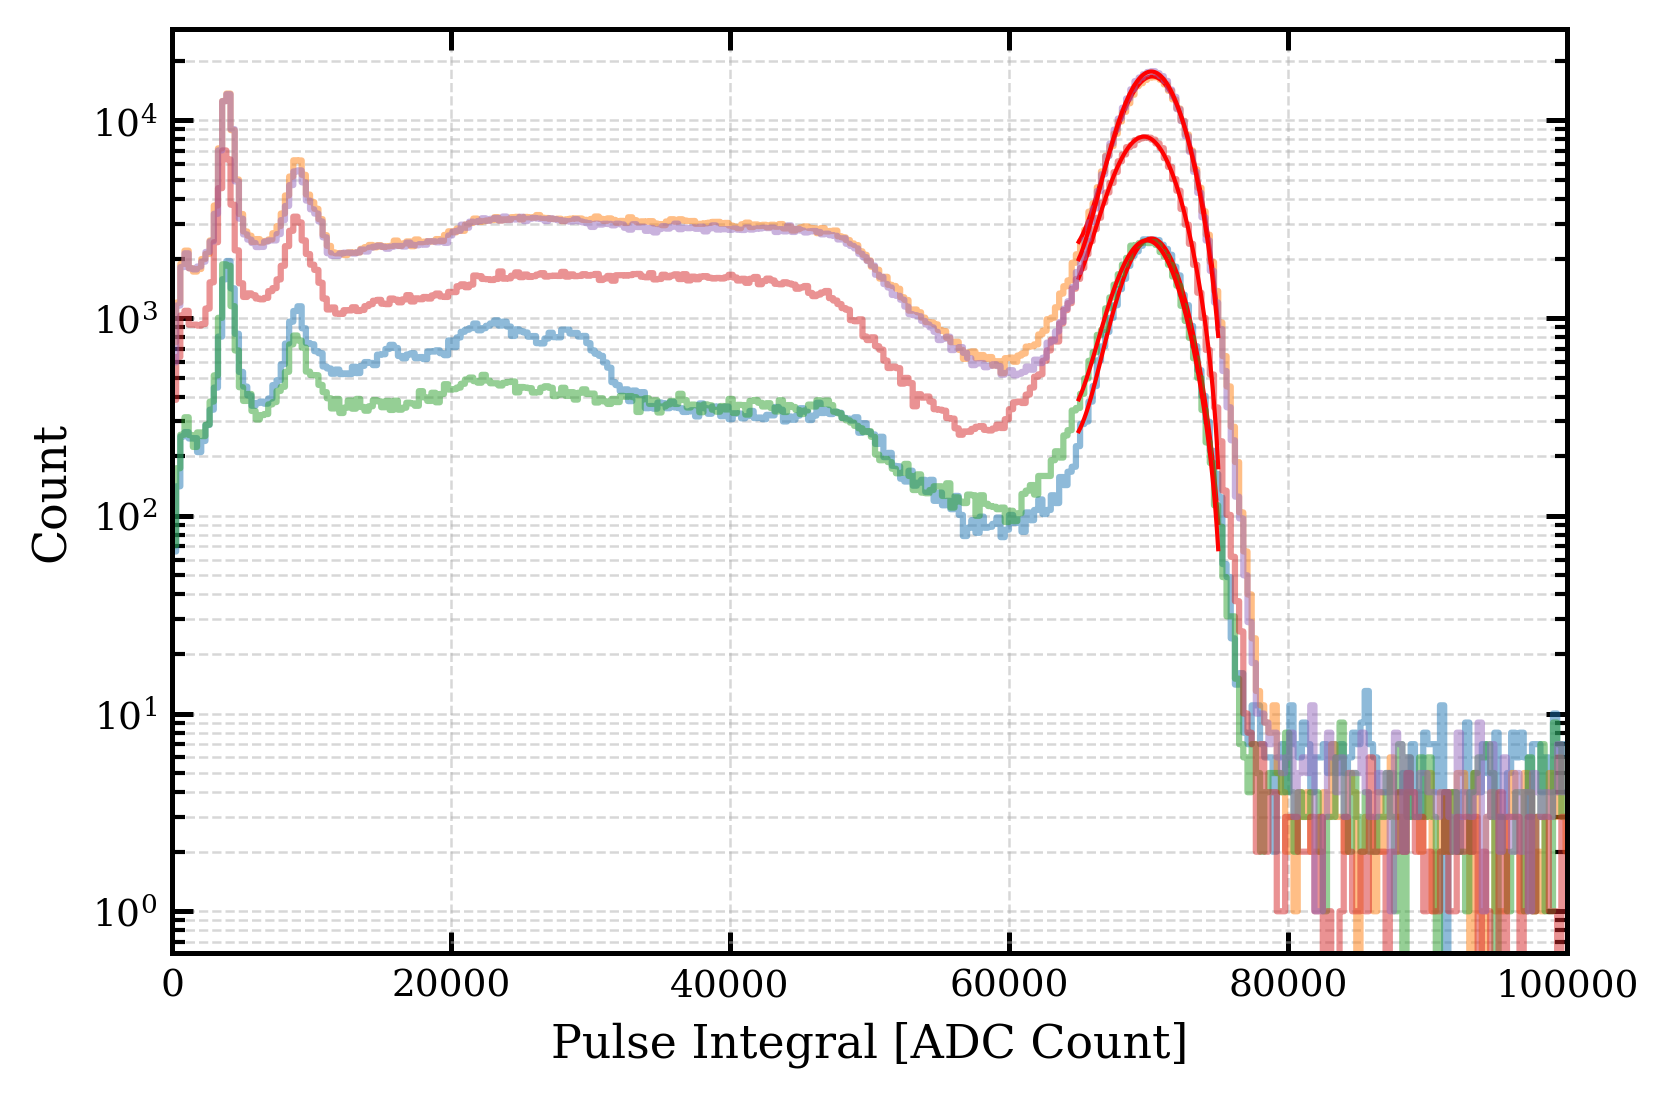

In [13]:
plt.figure(figsize=(8,6))

plt.figure()
plt.xlim([0,100000])
plt.xlabel("Pulse Integral [ADC Count]")
plt.ylabel("Count")
plt.yscale('log')

for run in ['top','east','west','south','north']:
    
    for i in [137]:
        counts, _ = np.histogram( pp_integral[mask & (runID==i) & (configID==(100+runinfo[run][0])) ], bins=bins );
        plt.plot( bin_centers, counts, drawstyle='steps-mid', alpha=0.5 )

        # 661.7 keV
        xmin = 65000
        xmax = 75000
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r', lw=1 )

        calibration[run].append([661.7,popt[1],popt[2]])

## Na-22: 511, 1274, 1785 keV

<Figure size 2400x1800 with 0 Axes>

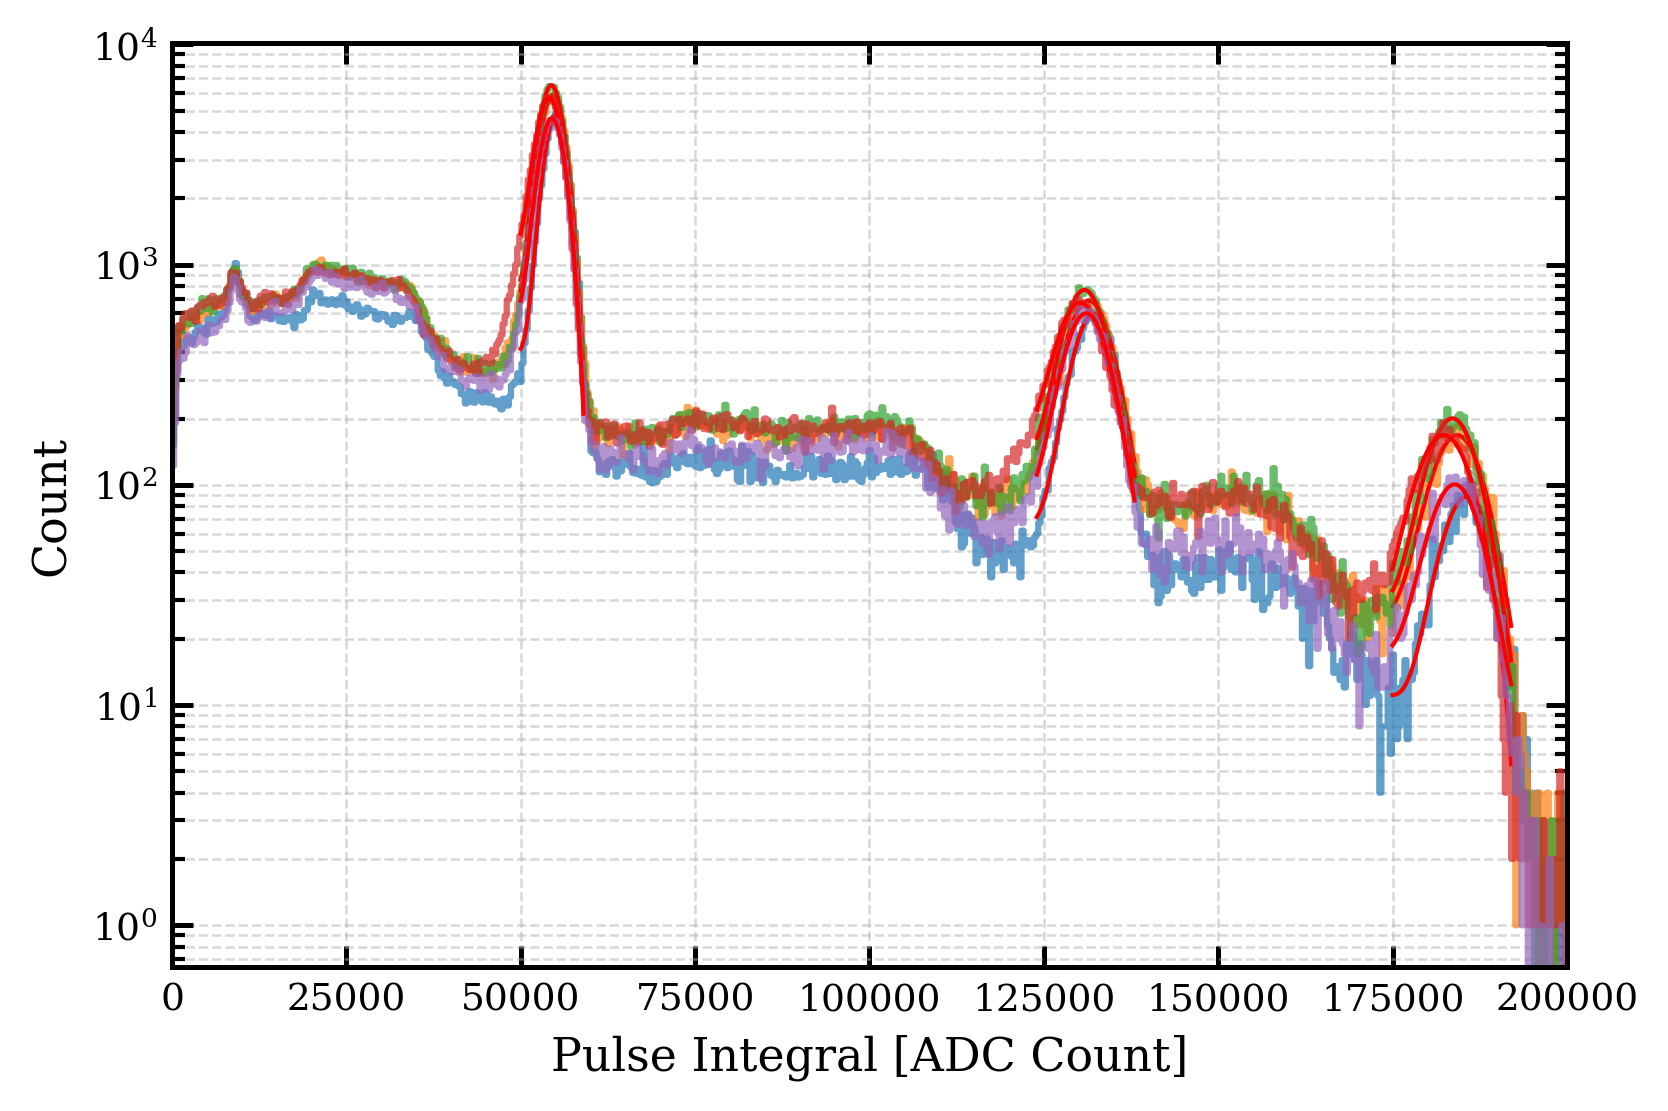

In [14]:
plt.figure(figsize=(8,6))

plt.figure()
plt.xlim([0,200000])
plt.yscale('log')
plt.xlabel("Pulse Integral [ADC Count]")
plt.ylabel("Count")

for run in ['top','east','west','south','north']:
    
    for i in [22]:
        counts, _ = np.histogram( pp_integral[mask & (runID==i) & (configID==(100+runinfo[run][0])) ], bins=bins );
        plt.plot( bin_centers, counts, drawstyle='steps-mid', alpha=0.7 )

        # 511 keV
        xmin = 50000
        xmax = 59000
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r', lw=1  )
        calibration[run].append([511,popt[1],popt[2]])
        
        # 1274 keV
        xmin = 124000
        xmax = 138000
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r', lw=1  )
        calibration[run].append([1274,popt[1],popt[2]])
        
        # 1785 keV
        xmin = 175000
        xmax = 192000
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r', lw=1  )
        calibration[run].append([511+1274,popt[1],popt[2]])

## Co-57 
This source was found to be actually Cs-137, since they have almost exactly same spectrum. Skipping...

## Co-60: 1173, 1274 keV

<Figure size 2400x1800 with 0 Axes>

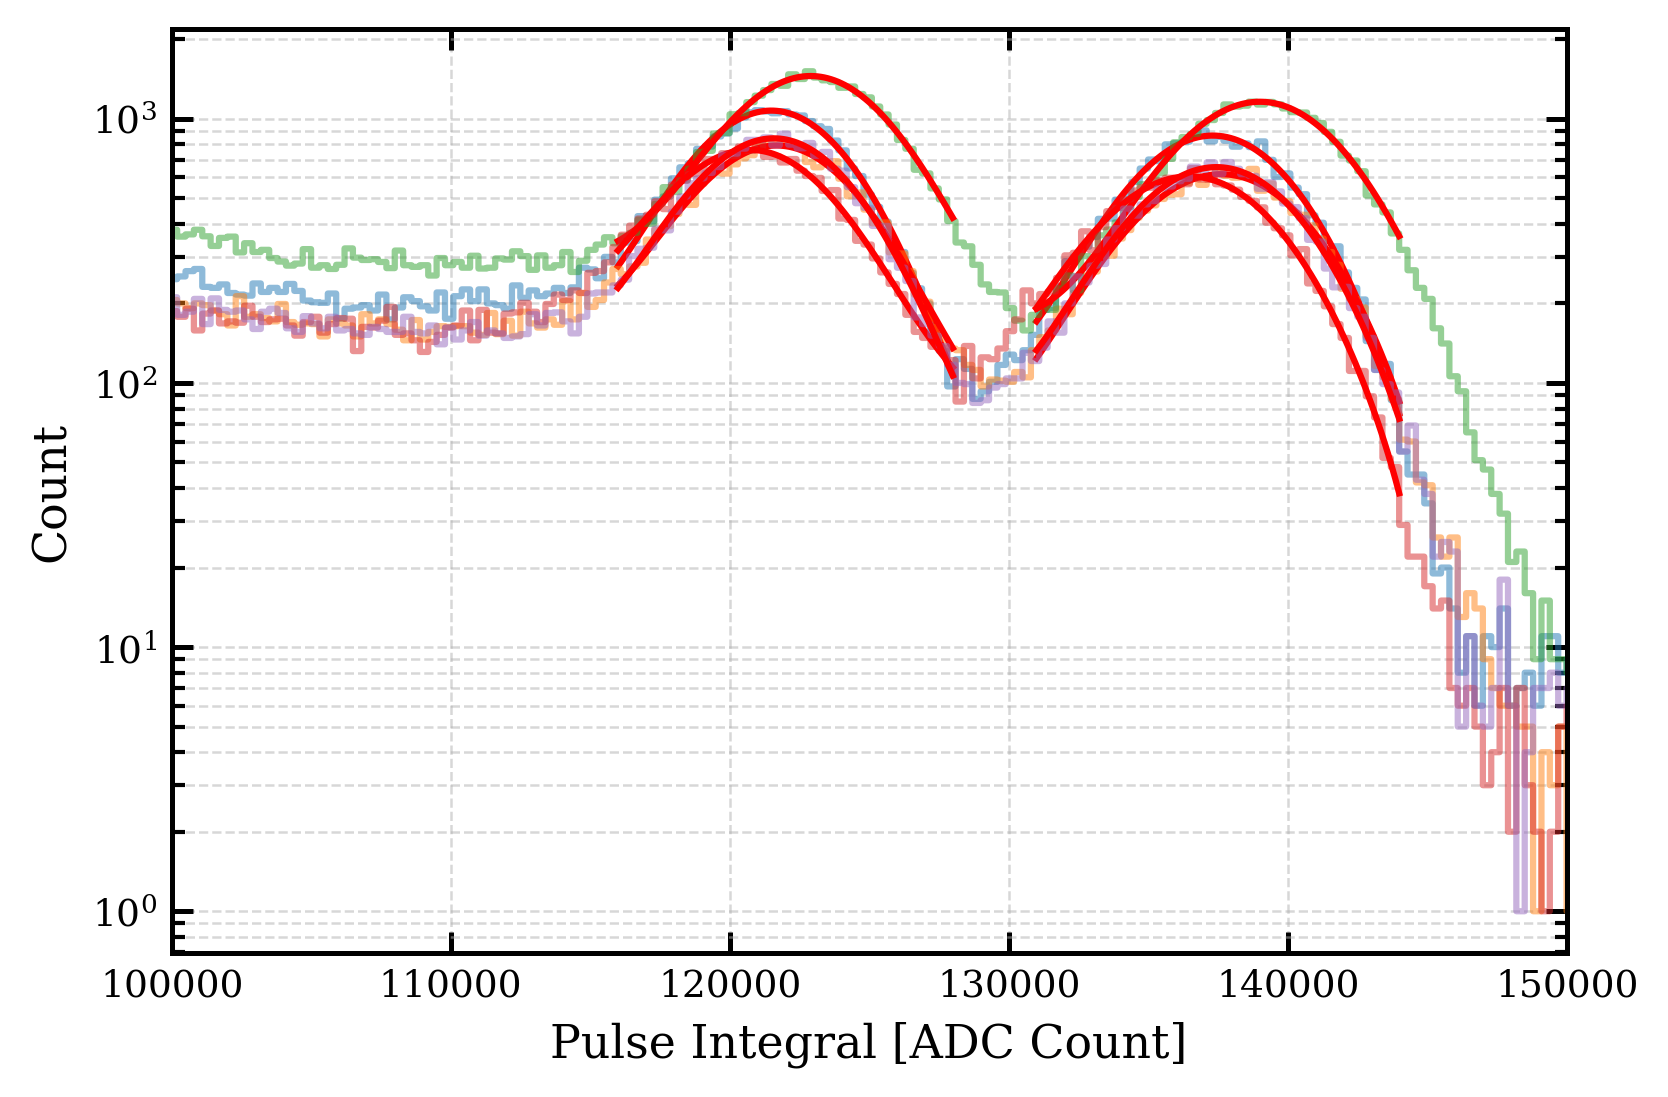

In [15]:
plt.figure(figsize=(8,6))

plt.figure()
plt.xlim([100000,150000])
plt.xlabel("Pulse Integral [ADC Count]")
plt.ylabel("Count")
plt.yscale('log')

for run in ['top','east','west','south','north']:
    
    for i in [60]:
        counts, _ = np.histogram( pp_integral[mask & (runID==i) & (configID==(100+runinfo[run][0])) ], bins=bins );
        plt.plot( bin_centers, counts, drawstyle='steps-mid', alpha=0.5 )

        # 1173 keV
        xmin = 116000
        xmax = 128000
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r' )
        #calibration[run].append([1173,popt[1],popt[2]])
        
        # 1332 keV
        xmin = 131000
        xmax = 144000
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r' )
        #calibration[run].append([1332,popt[1],popt[2]])

## Ba-133: 31, 81, 356 keV

<Figure size 2400x1800 with 0 Axes>

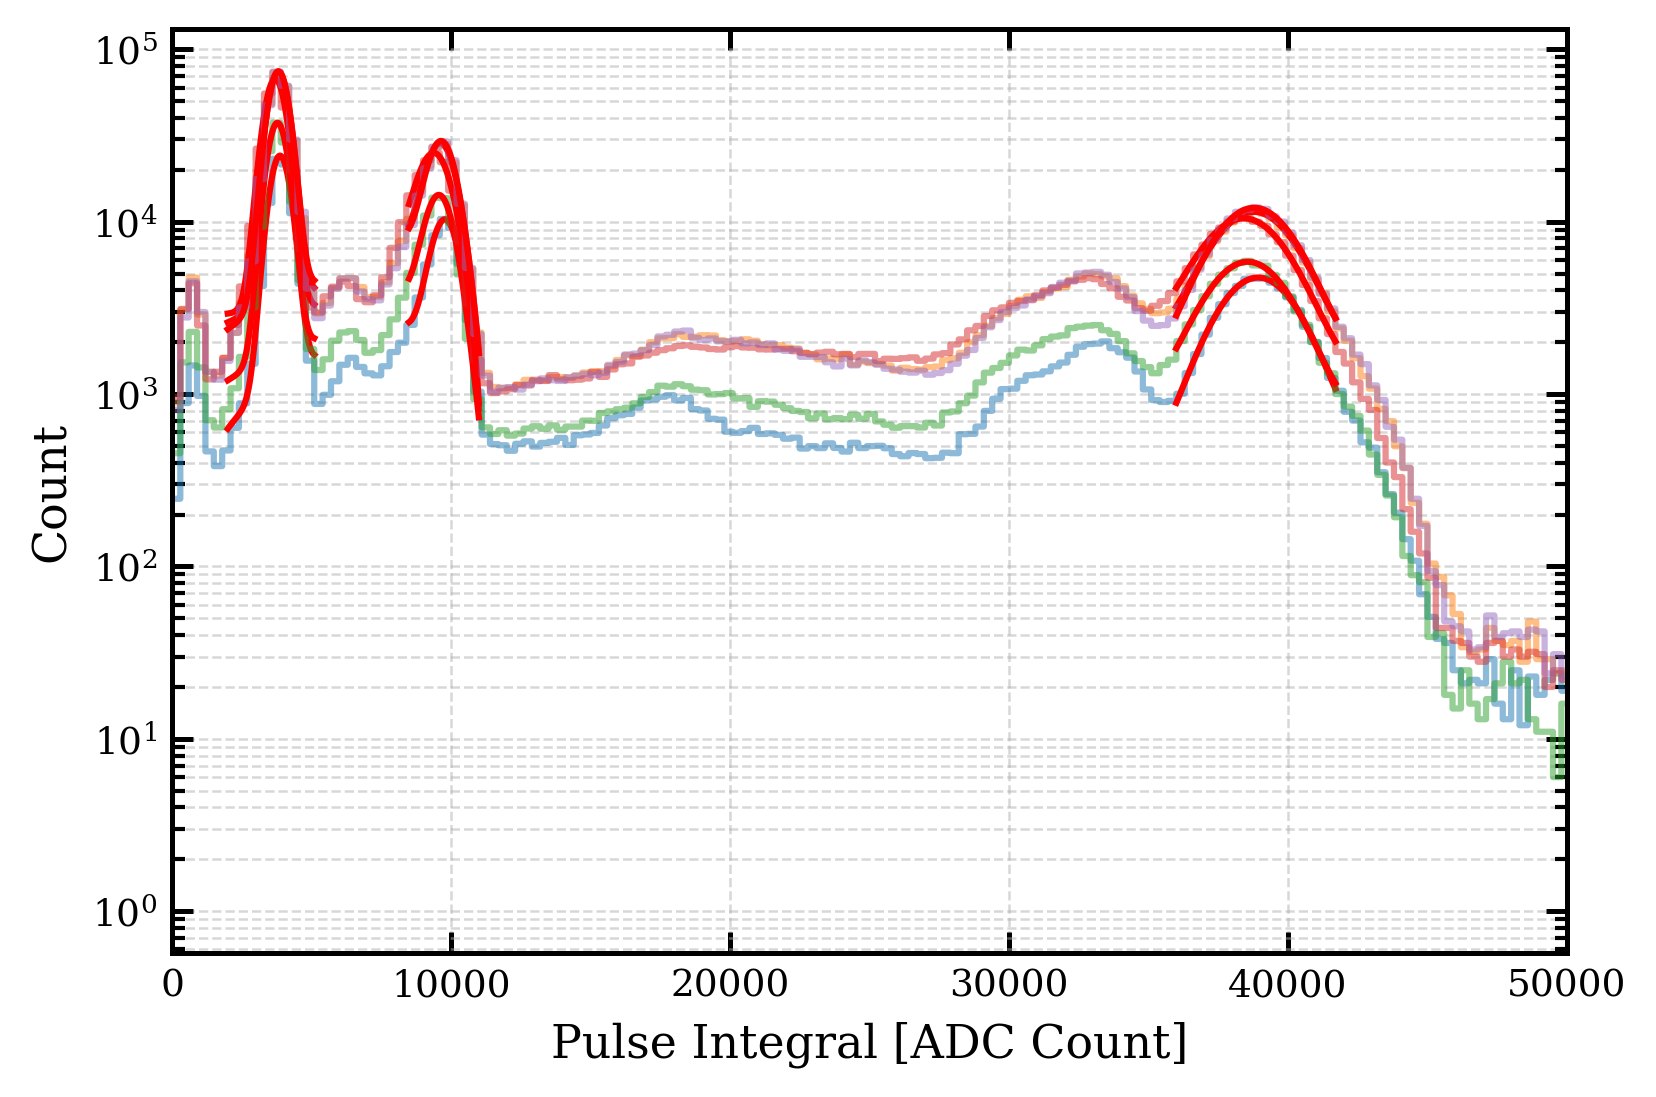

In [16]:
plt.figure(figsize=(8,6))

plt.figure()
plt.xlim([0,50000])
plt.xlabel("Pulse Integral [ADC Count]")
plt.ylabel("Count")
plt.yscale('log')

for run in ['top','east','west','south','north']:
    
    for i in [133]:
        counts, _ = np.histogram( pp_integral[mask & (runID==i) & (configID==(100+runinfo[run][0])) ], bins=bins );
        plt.plot( bin_centers, counts, drawstyle='steps-mid', alpha=0.5 )

        # 31-keV
        xmin = 2000
        xmax = 5100
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r' )
        calibration[run].append([31,popt[1],popt[2]])
        
        # 81-keV
        xmin = 8500
        xmax = 11000
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r' )
        calibration[run].append([81,popt[1],popt[2]])
        
        # 356-keV
        xmin = 36000
        xmax = 41700
        popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
        plt.plot( x_fit, y_fit, c='r' )
        calibration[run].append([356,popt[1],popt[2]])

## Internal Calibrations

<Figure size 2400x1800 with 0 Axes>

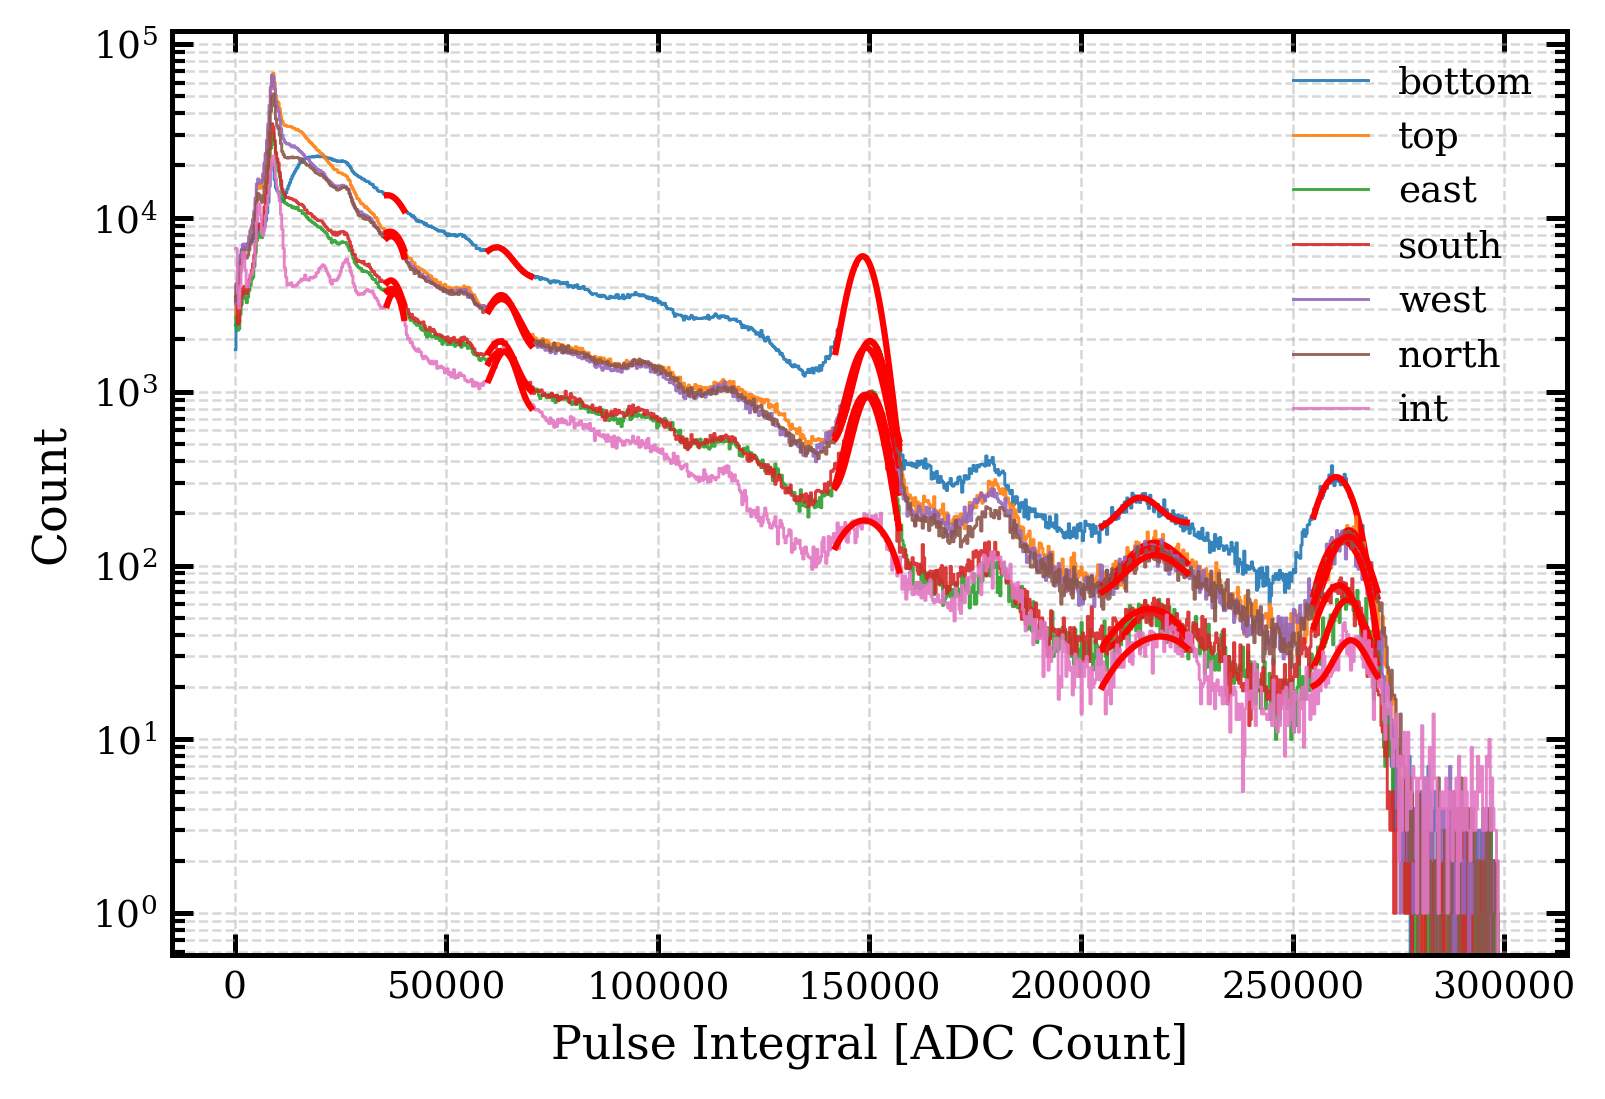

In [17]:
plt.figure(figsize=(8,6))

plt.figure()
#plt.xlim([20000,50000])
plt.xlabel("Pulse Integral [ADC Count]")
plt.ylabel("Count")
plt.yscale('log')

nbins = 1000
bins = np.linspace(0, 3e5, nbins)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

for key in runinfo.keys():
    
    nrun = runinfo[key][1]
    counts, _ = np.histogram( pp_integral[mask & (runID<=runinfo[key][1]) & (configID==(runinfo[key][0])) ], bins=bins );
    plt.plot( bin_centers, counts, drawstyle='steps-mid', alpha=0.9, label=key, linewidth=0.7 )
    
    # 1460-keV
    xmin = 142000
    xmax = 157000
    popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
    plt.plot( x_fit, y_fit, c='r' )
    calibration[key].append([1460,popt[1],popt[2]])
        
    # 2614-keV
    xmin = 255000
    xmax = 270000
    popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
    plt.plot( x_fit, y_fit, c='r' )
    calibration[key].append([2614,popt[1],popt[2]])

    # 609-keV
    xmin = 60000
    xmax = 70000
    popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
    plt.plot( x_fit, y_fit, c='r' )
    #calibration[key].append([609,popt[1],popt[2]])
    #calibration[key].append([609,popt[1],None])
    
    # 352-keV
    xmin = 36000
    xmax = 40000
    popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
    plt.plot( x_fit, y_fit, c='r' )
    #calibration[key].append([352,popt[1],popt[2]])
    #calibration[key].append([352,popt[1],None])

    # 2204 keV
    xmin = 205000
    xmax = 225000
    popt, x_fit, y_fit = fit_gamma( bin_centers, counts, xmin, xmax )
    plt.plot( x_fit, y_fit, c='r' )
    #calibration[key].append([2204,popt[1],popt[2]])
    #calibration[key].append([2204,popt[1],None])

plt.legend()

The variable `cal` stores extracted energy calibration information. 

Each column represents:

**energy [keV], peak position [ADC count], standard deviation of the peak [ADC count]**

In [18]:
print( np.sort(calibration['top']) )
print(calibration['bottom'])

[[6.61700000e+02 2.01571195e+03 7.02582674e+04]
 [5.11000000e+02 1.68391319e+03 5.50965157e+04]
 [1.27400000e+03 2.94972432e+03 1.32223203e+05]
 [1.78500000e+03 3.42449164e+03 1.85746441e+05]
 [3.10000000e+01 3.67859238e+02 3.87186778e+03]
 [8.10000000e+01 4.94868442e+02 9.80557108e+03]
 [3.56000000e+02 1.44076124e+03 3.89267173e+04]
 [1.46000000e+03 3.12081302e+03 1.50251521e+05]
 [2.61400000e+03 3.81877485e+03 2.63389634e+05]]
[[1460, np.float64(148484.32059418486), np.float64(3419.2574184261366)], [2614, np.float64(260367.49319151422), np.float64(5260.49183139305)]]


## Plot and fit calibration curve

## Light Yield

Assuming a functional form of $y = k\times x + b$

/tmp/ipykernel_1212434/2032629362.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear, x, y)


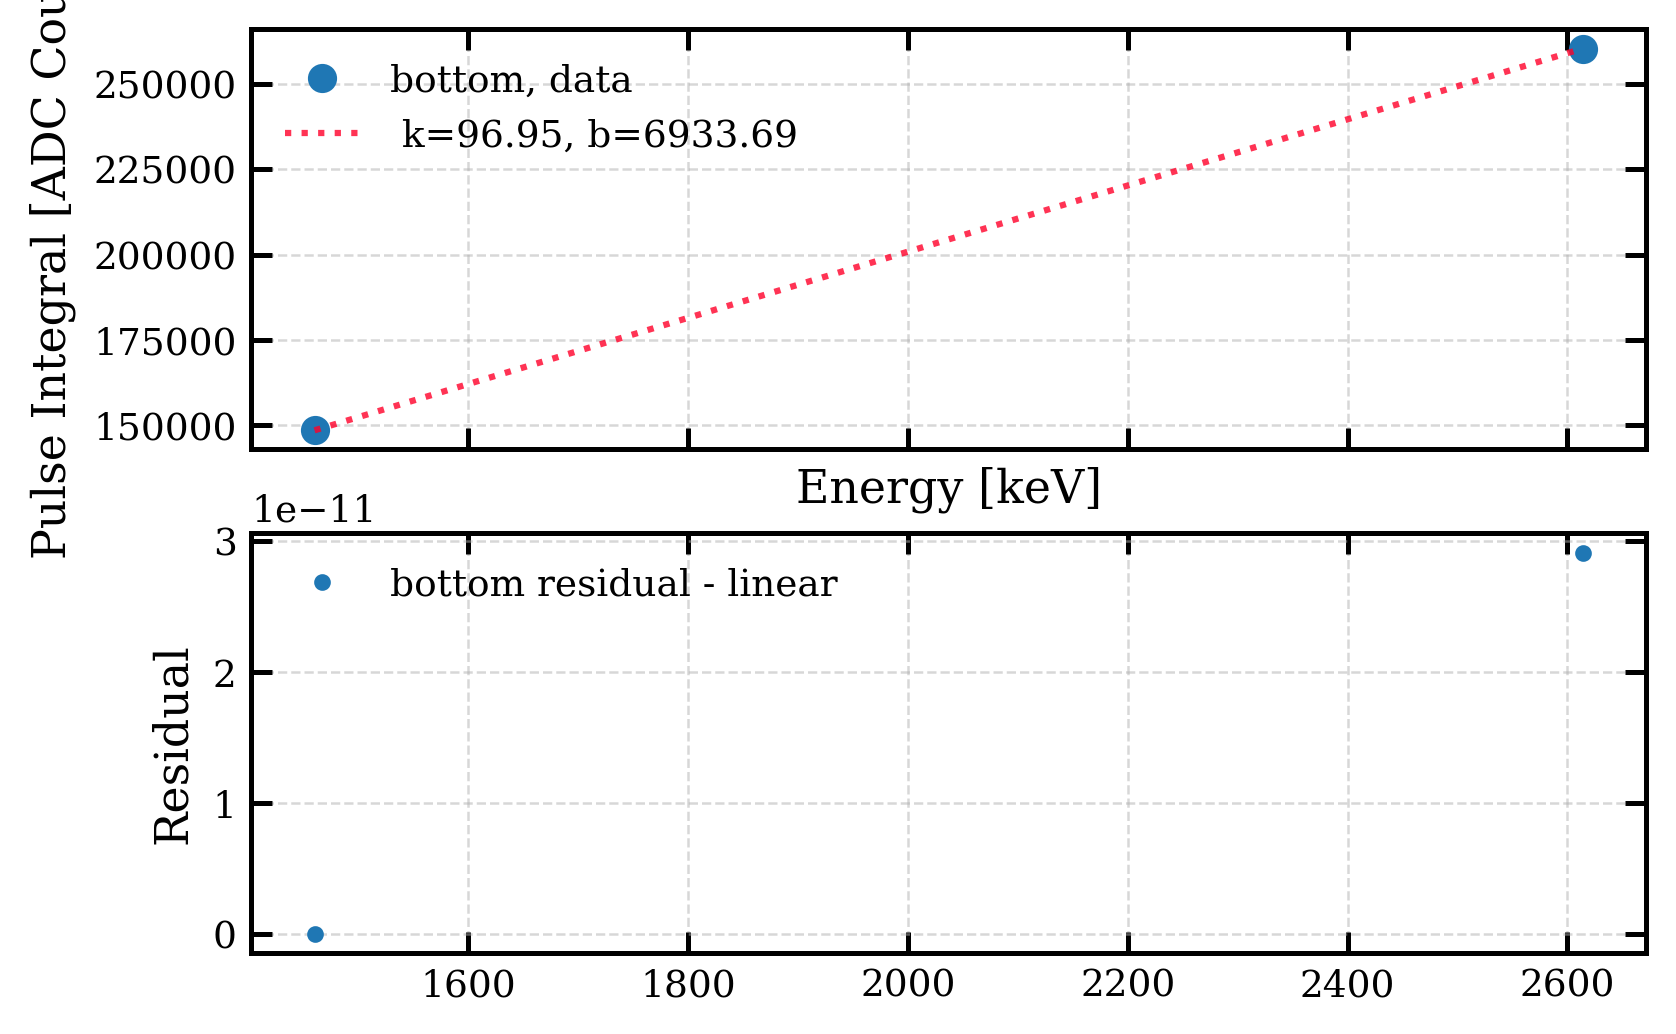

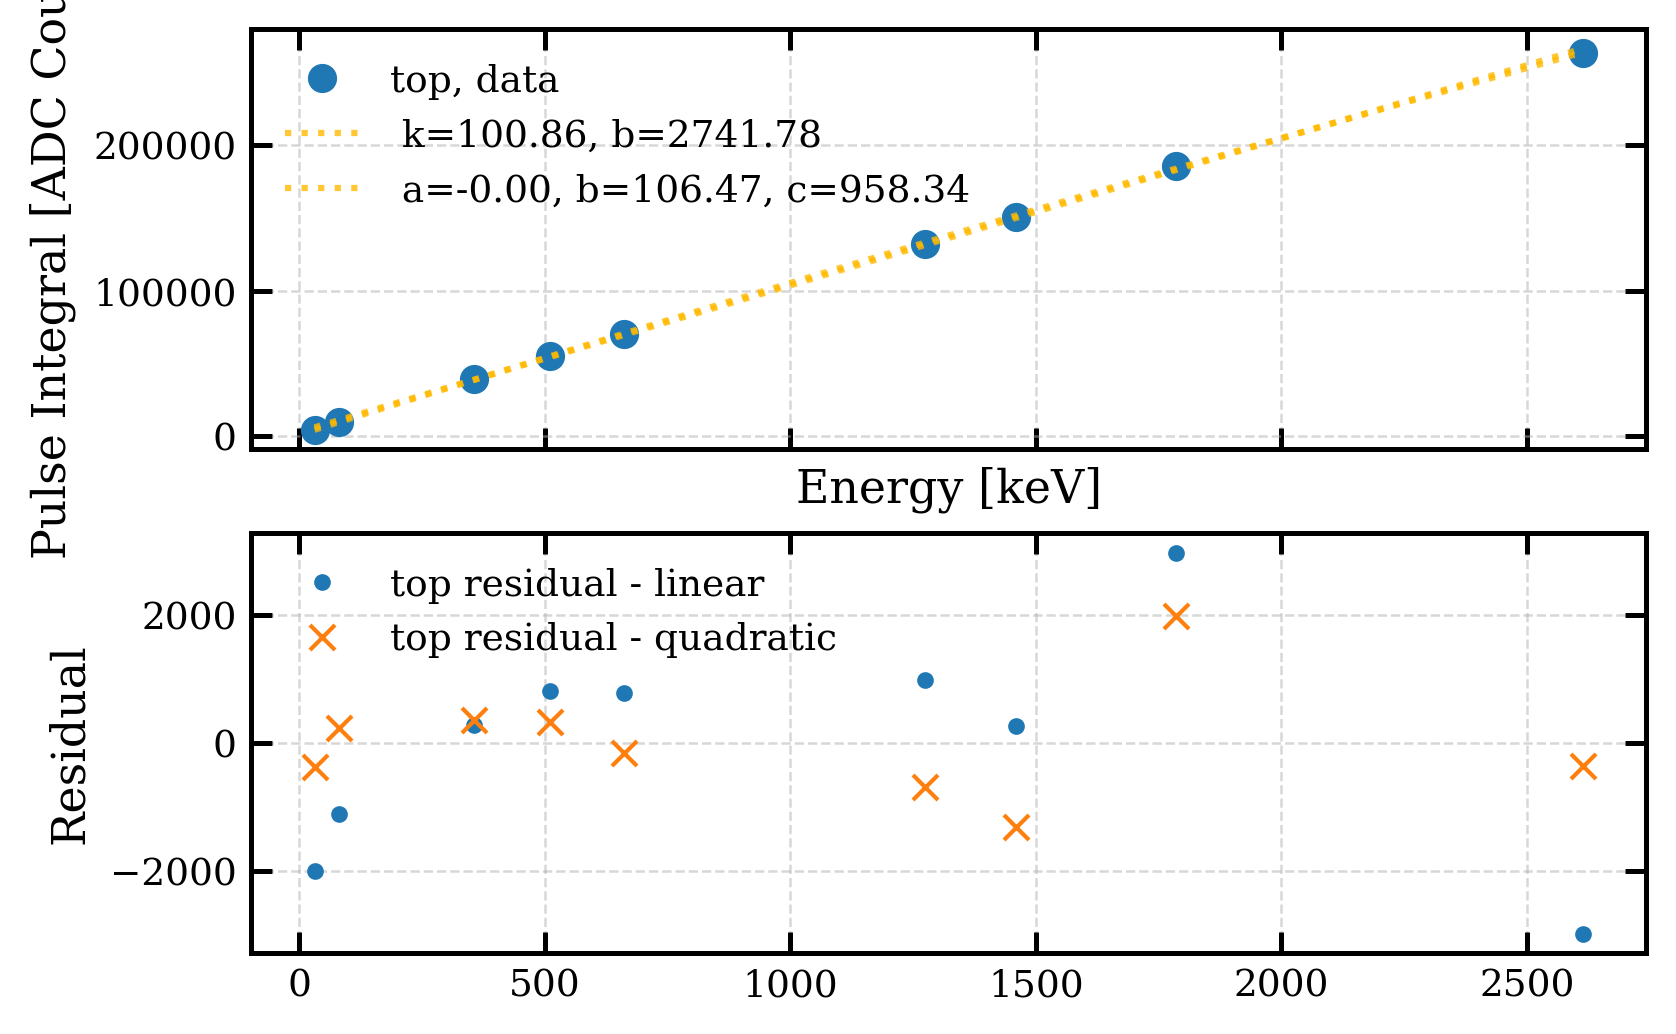

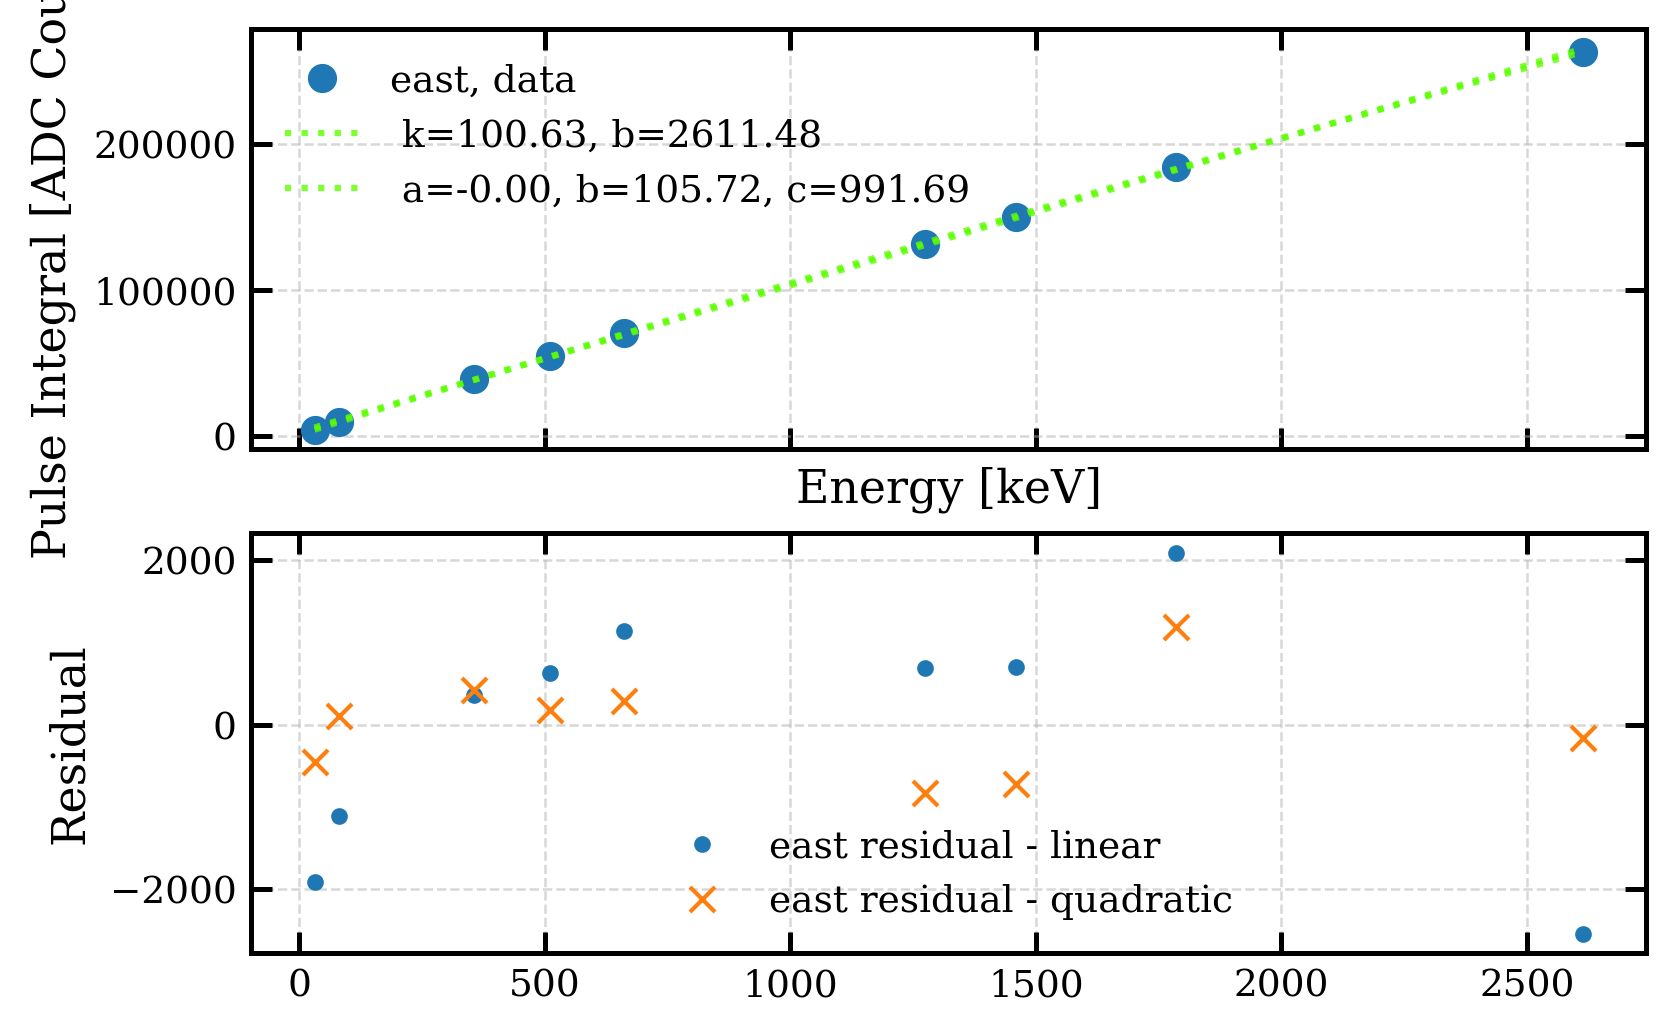

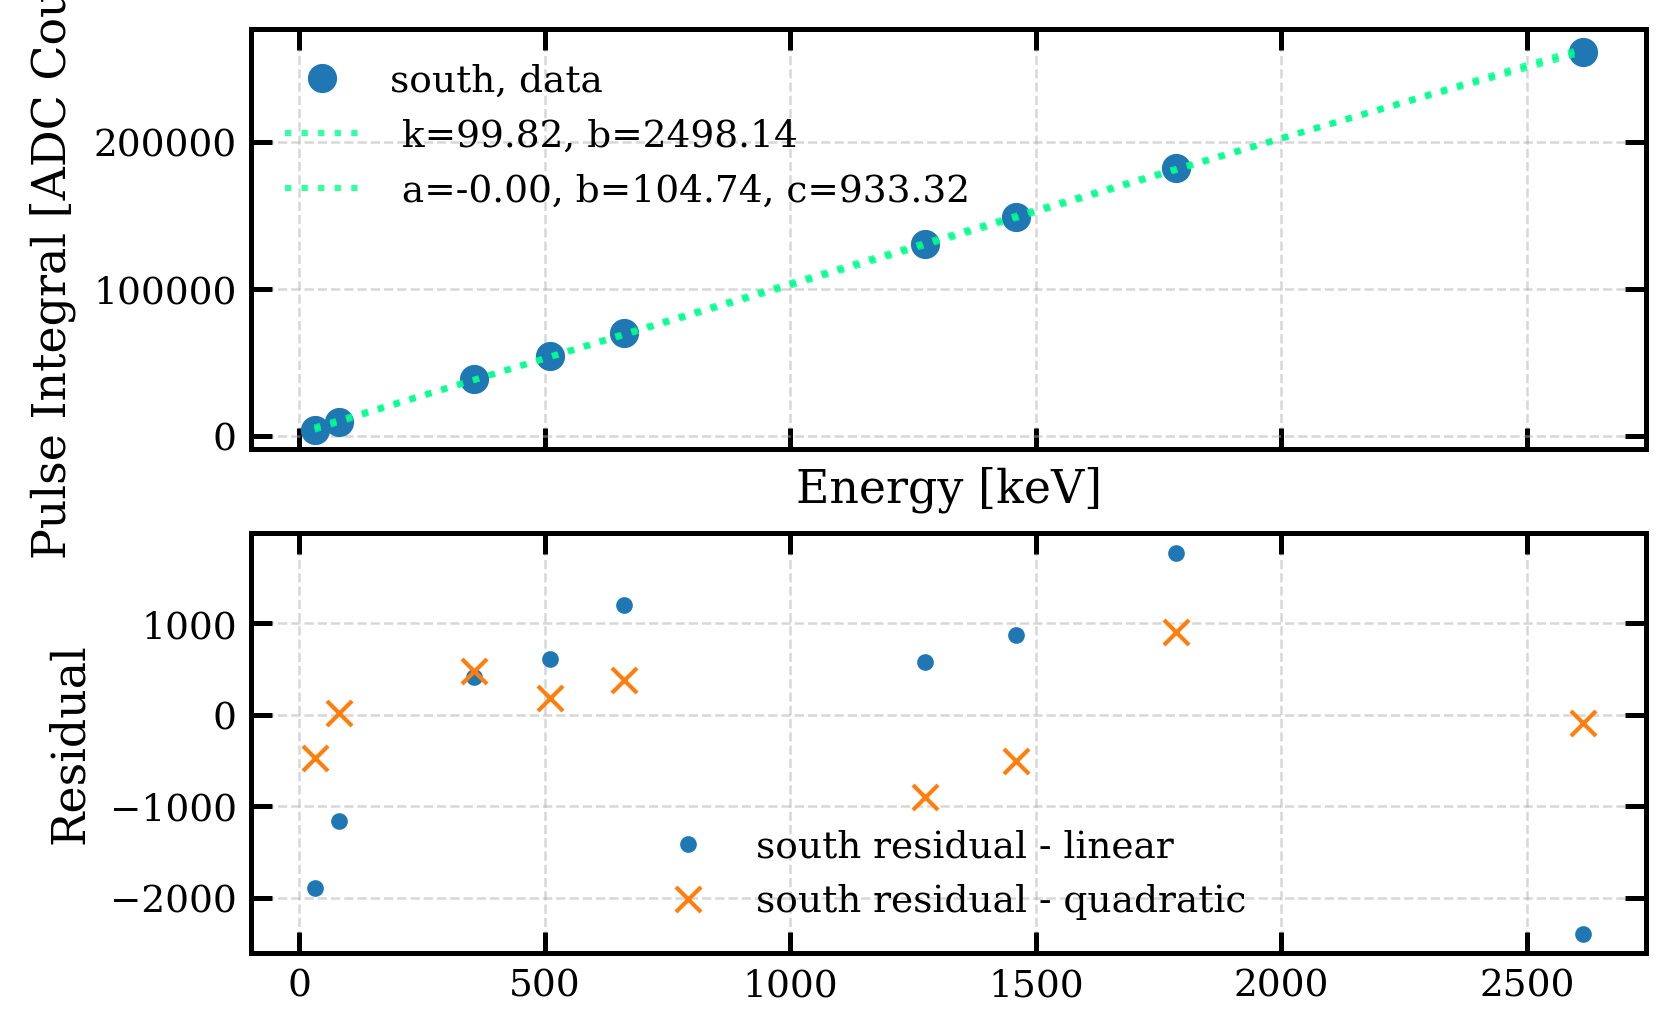

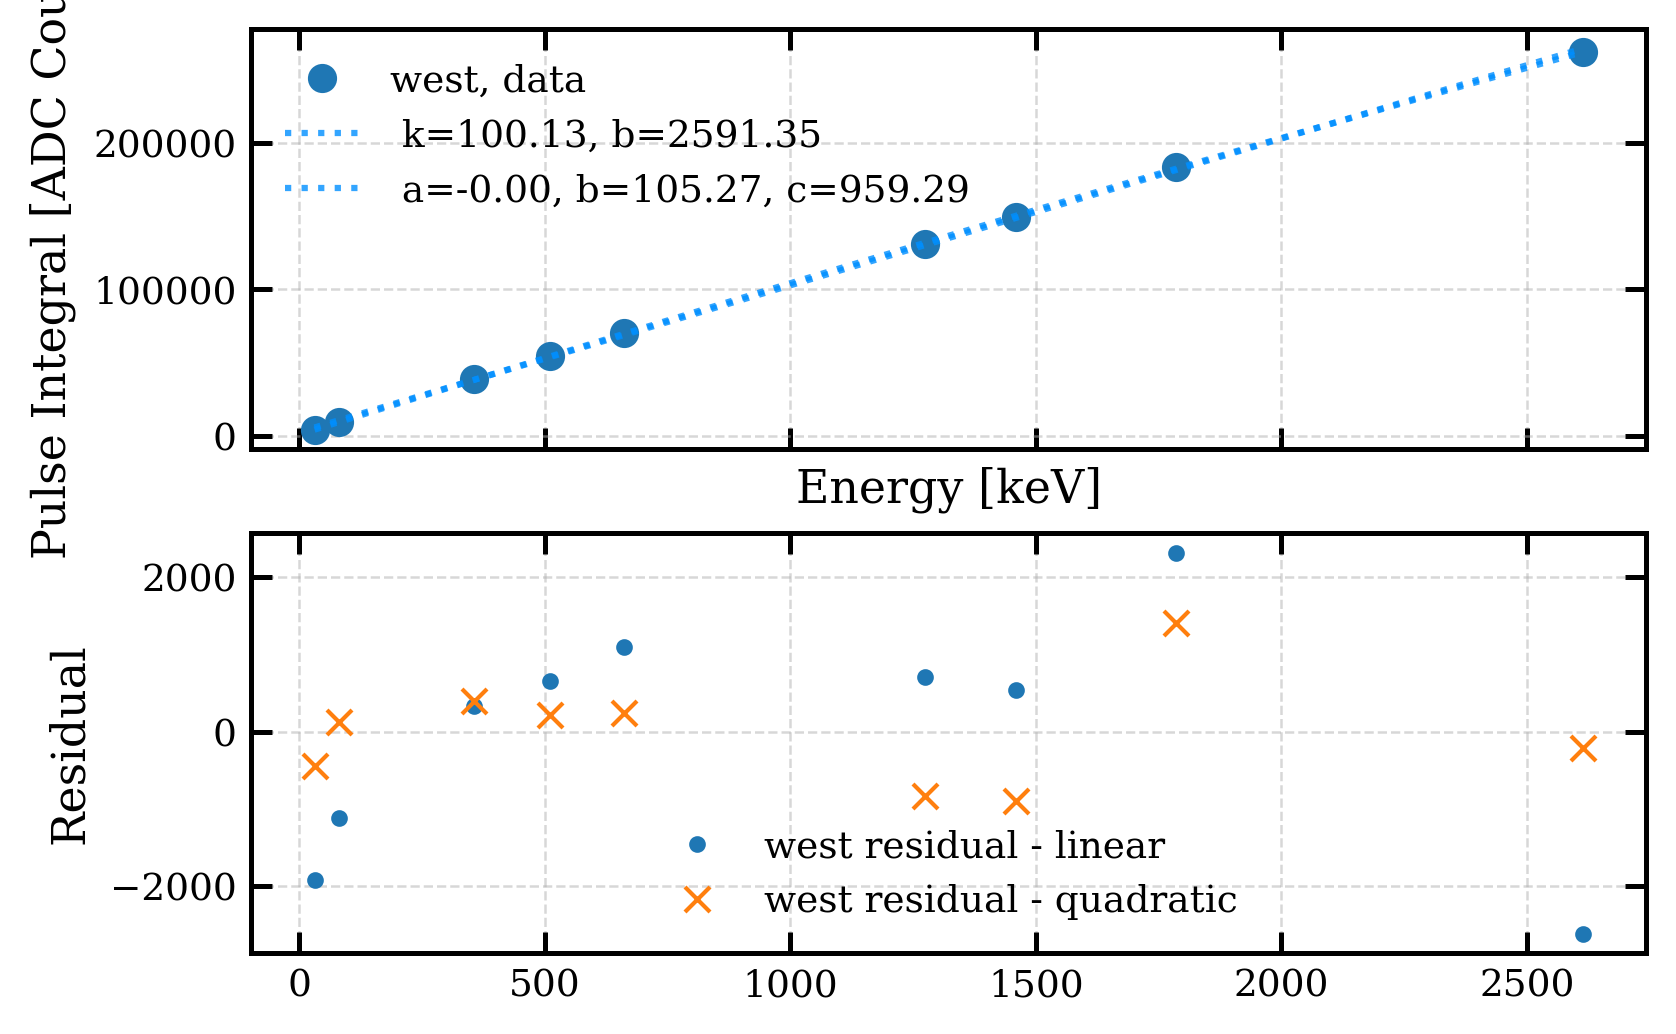

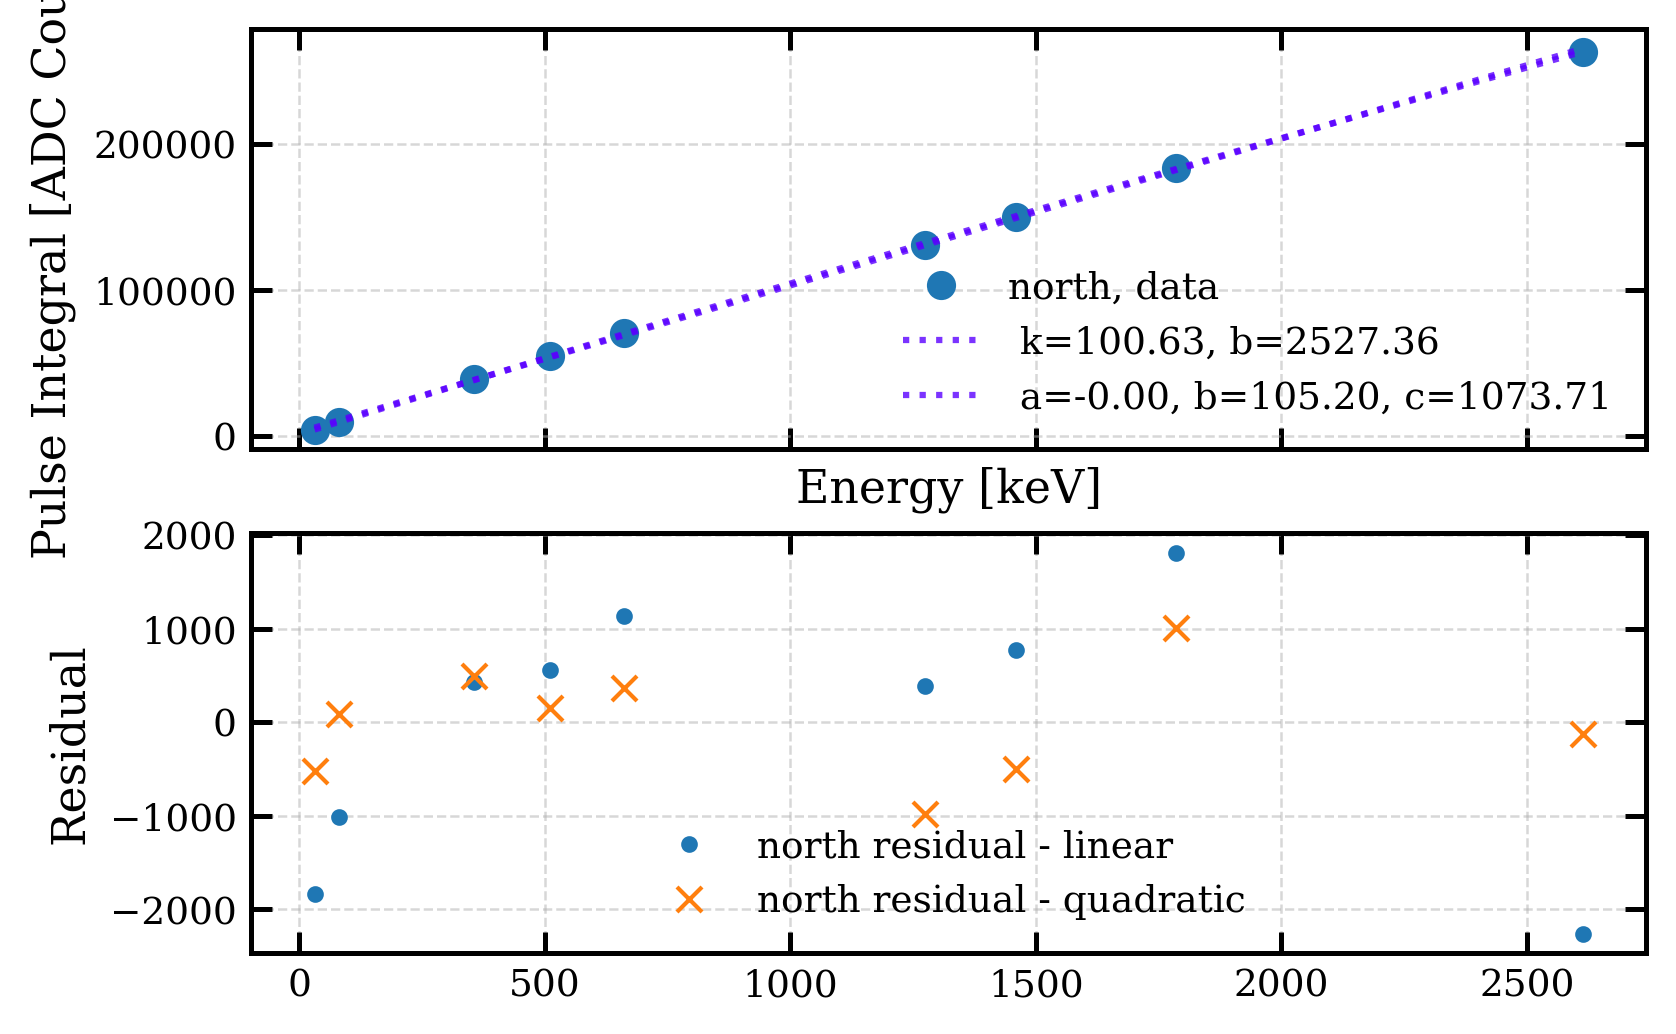

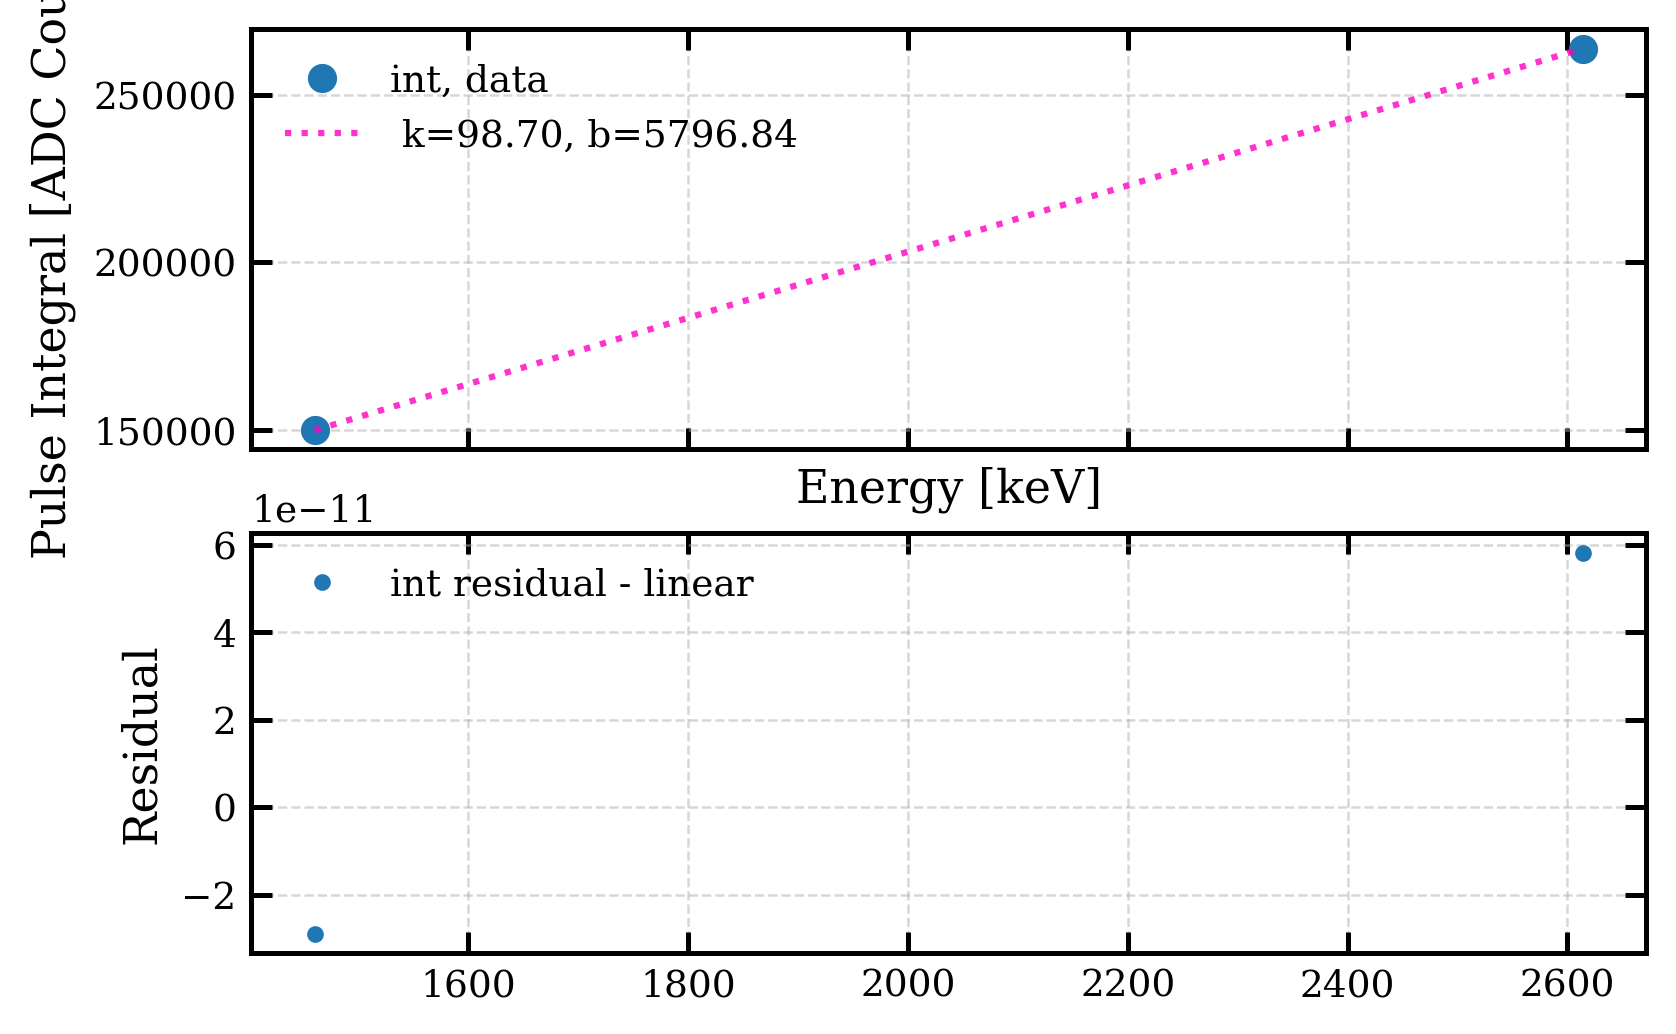

In [19]:
import matplotlib.cm as cm

def linear(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c
    
def fit_linear(x, y):
    popt, pcov = curve_fit(linear, x, y)
    return popt
    
def fit_quadratic(x, y):
    popt, pcov = curve_fit(quadratic, x, y)
    return popt
    
colors = cm.gist_rainbow(np.linspace(0, 1, len(calibration)))

# variable to store the result of light yield calibration
calibration_ly = {}

for n,i in enumerate(calibration.keys()):

    fig, ax = plt.subplots( 2, 1, sharex = True)
    ax[0].set_xlabel('Energy [keV]')
    ax[0].set_ylabel('Pulse Integral [ADC Count]')
    ax[1].set_ylabel('Residual')
    
    color = colors[n]
    
    calibration_sorted = sorted(calibration[i], key=lambda row: row[0])
    cal = np.asarray(calibration_sorted)

    ax[0].plot( cal[:,0], cal[:,1], linestyle='none', marker='o', label=i+', data' )
    
    x = np.linspace( cal[:,0][0], cal[:,0][-1], 100 )
    
    k,b = fit_linear( cal[:,0], cal[:,1] )
    ax[0].plot( x, linear(x, k, b), linestyle=':', color=color, label=" k={:.2f}, b={:.2f}".format(k,b), alpha=0.8)
    ax[1].plot( cal[:,0], cal[:,1] - linear(cal[:,0], k, b), linestyle='none', marker='.', label=i+' residual - linear' )
    calibration_ly[i] = [k,b]
    
    if len( cal[:,0] ) > 2:
        a,b,c = fit_quadratic( cal[:,0], cal[:,1] )
        ax[0].plot( x, a*x**2+b*x+c, linestyle=':', color=color, label=" a={:.2f}, b={:.2f}, c={:.2f}".format(a,b,c), alpha=0.8)
        ax[1].plot( cal[:,0], cal[:,1] - quadratic(cal[:,0], a, b, c), linestyle='none', marker='x', label=i+' residual - quadratic' )
        calibration_ly[i].append(b)
        calibration_ly[i].append(b)
        calibration_ly[i].append(c)

    ax[0].legend()
    ax[1].legend()

## Energy Resolution
Assuming a functional form of:

$\dfrac{\sigma}{E}=\sqrt{a + \dfrac{b}{E}+\dfrac{c}{E^2}}$

Therefore, the actual energy resolution/standard deviation is:

$\sigma(E)=\sqrt{c + bE + aE^2}$

/tmp/ipykernel_1212434/2400271551.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, E, R, p0=p0, bounds=bounds)


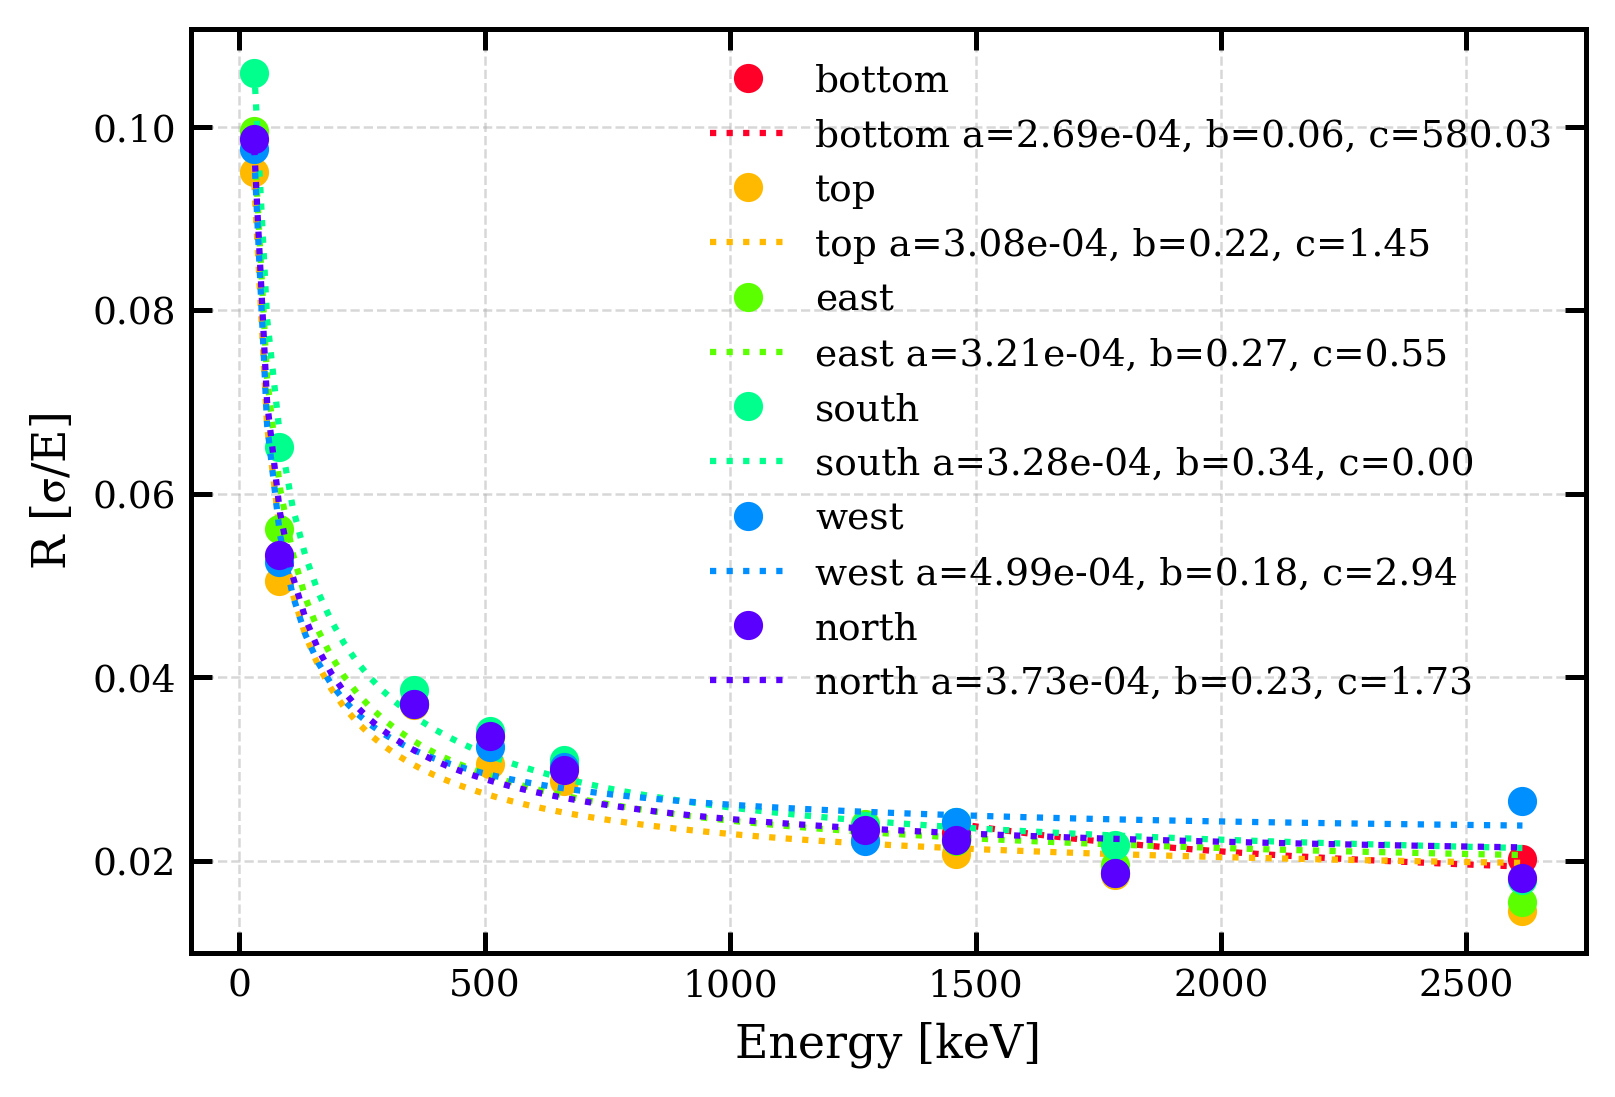

In [20]:
def fit_resolution(E, R):
    def model(E, a, b, c):
        return np.sqrt( a + b/E + c/E**2)
    p0 = [0, 1000, 10000]
    bounds = ([0,0,0],[np.inf, np.inf, np.inf])
    popt, pcov = curve_fit(model, E, R, p0=p0, bounds=bounds)
    return popt
    
colors = cm.gist_rainbow(np.linspace(0, 1, len(calibration)))

# variable to store fitted resolution
calibration_resolution = {}

plt.figure()
plt.xlabel( 'Energy [keV]')
plt.ylabel( r'R [$\sigma$/E]')

for n,i in enumerate(calibration.keys()):

    if i=='int':
        continue

    color = colors[n]
    
    calibration_sorted = sorted(calibration[i], key=lambda row: row[0])
    cal = np.asarray(calibration_sorted)
    cal = cal[cal[:,2]!=None]
    
    a,b,c = fit_resolution( cal[:,0], cal[:,2]/cal[:,1] )
    plt.plot(cal[:,0],cal[:,2]/cal[:,1],linestyle='none', color=color, marker='o', label=i)

    calibration_resolution[i] = [a,b,c]
    
    x = np.linspace(cal[:,0][0],cal[:,0][-1],100)
    plt.plot( x, np.sqrt(a+b/x+c/x**2), linestyle=':', color=color, label=i+" a={:.2e}, b={:.2f}, c={:.2f}".format(a,b,c))
plt.legend()

### Treat the calibration of bottom and internal differently.

Bottom is the same as top, internal is the average of all others

In [21]:
'''
calibration_ly['bottom'] = calibration_ly['top'].copy()
calibration_resolution['bottom'] = calibration_resolution['top'].copy()
'''
calibration_ly['int'] = np.mean( np.array(list(calibration_ly.values())), axis=0 ).tolist()
calibration_resolution['int'] = np.mean( np.array(list(calibration_resolution.values())), axis=0 ).tolist()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (7,) + inhomogeneous part.

At this point, `calibration_ly` and `calibration_resolution` contains the functional form of light yield and energy resolution

In [22]:
# e.g. for bottom:
print( calibration_ly['bottom'] )
print( calibration_resolution['bottom'] )

[np.float64(96.95248925245177), np.float64(6933.686285605273)]
[np.float64(0.00026882529540685424), np.float64(0.05591595992578607), np.float64(580.0346945481366)]


***
## Plot Background Spectra after Calibration

First, spectrum is generated for each configuration by 
- applying the calibration curve
- histogram into 1 keV bins
- divide the final count by the corresponding livetime

### Redefine bins in the true energy scale

In [23]:
nbins = 3000
bins = np.linspace(0, 3000, nbins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

binwidth = bin_centers[1]-bin_centers[0]

In [24]:
# Process and store the results in a dictionary

spectrum = {}

for key in ['int']:

    val = runinfo[key]
    conf = val[0]
    nrun = val[1]

    mask_config = (runID<=nrun) & (configID==conf)
    mask_accept = mask & (pp_flag==0) & mask_config

    k,b = calibration_ly[key]
    counts, _ = np.histogram( k*pp_integral[mask_accept]+b, bins=bins );
    counts_int = counts / (livetime[key] * binwidth)

    spectrum[key] = counts_int

for key,val in runinfo.items():

    if key == 'int':
        continue
    
    conf = val[0]
    nrun = val[1]

    mask_config = (runID<=nrun) & (configID==conf)
    mask_accept = mask & (pp_flag==0) & mask_config

    if key == 'bottom':
        kk,bb = calibration_ly[key]
        k = 1/kk
        b = -bb/kk
        counts, _ = np.histogram( k*pp_integral[mask_accept]+b, bins=bins );
    else:
        k,b,a,b,c = calibration_ly[key]
        k = 1/kk
        b = -bb/kk
        counts, _ = np.histogram( k*pp_integral[mask_accept]+b, bins=bins );

    
    spectrum[key] = counts/livetime[key]/binwidth - counts_int

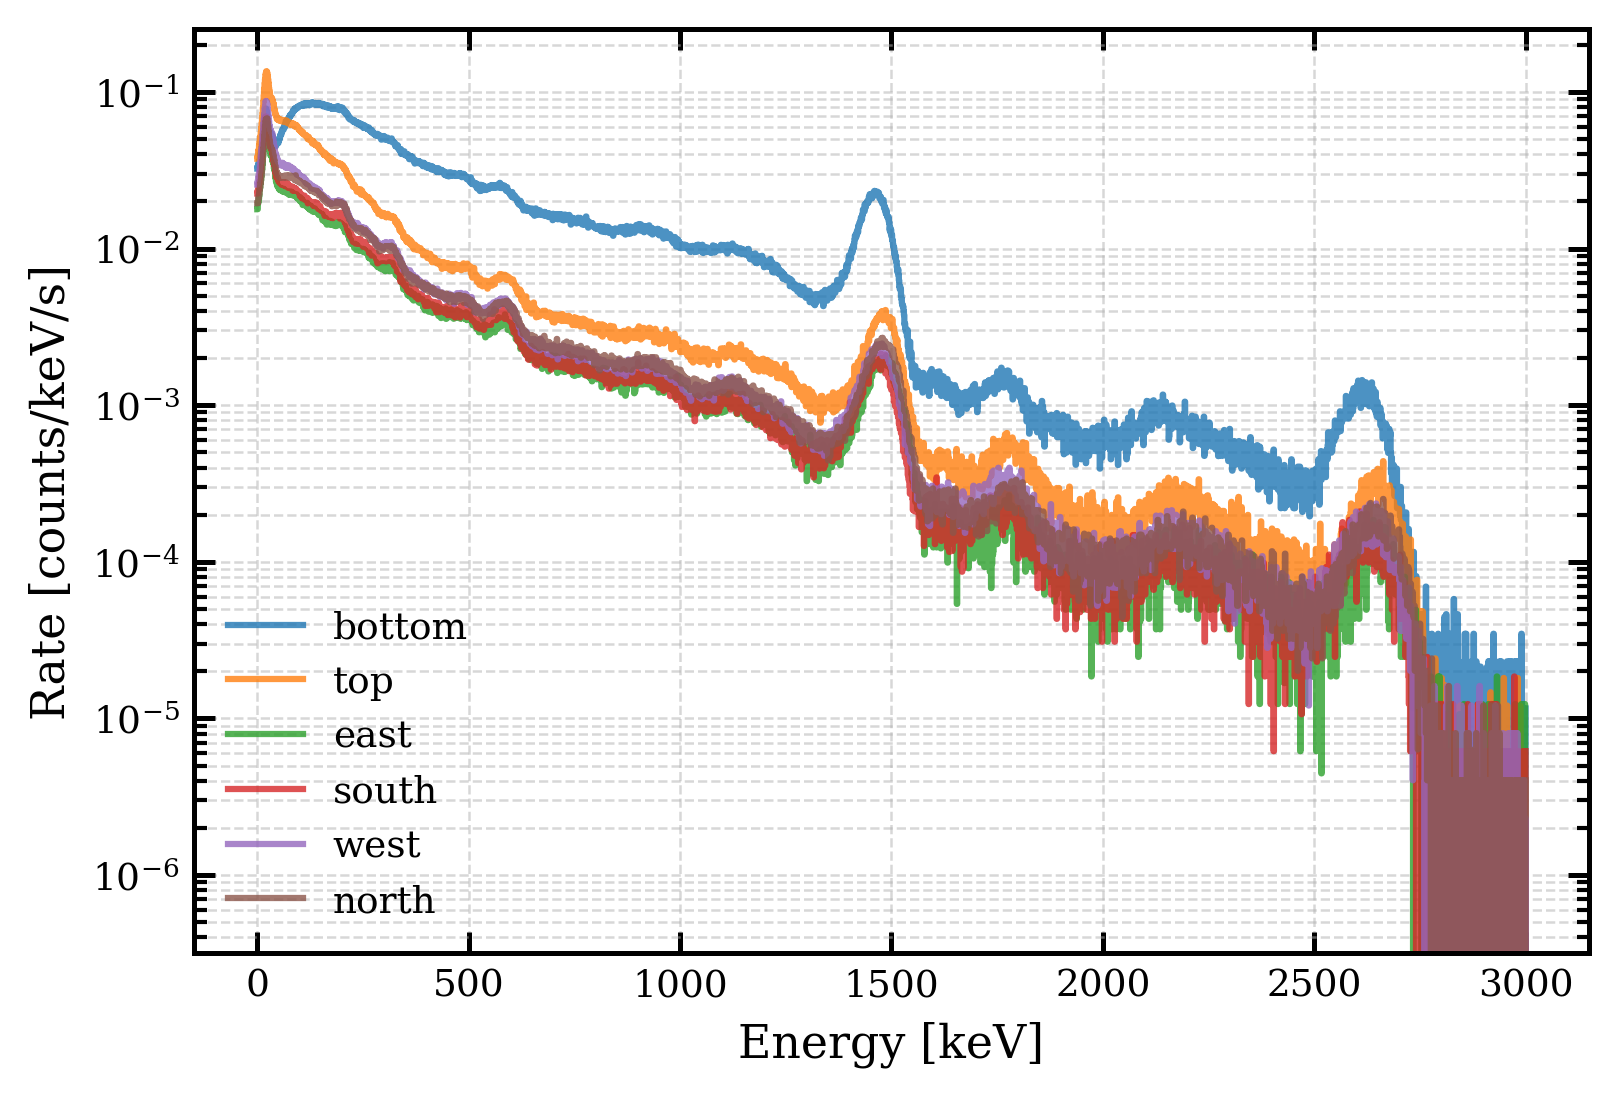

In [25]:
plt.figure()
plt.xlabel('Energy [keV]')
plt.ylabel('Rate [counts/keV/s]')
plt.yscale('log')
#plt.xlim([1400,1600])

for key,val in spectrum.items():
    if key == 'int':
        continue
    plt.plot( bin_centers, spectrum[key], drawstyle='steps-post', alpha=0.8, label=key)
plt.legend()

At this point, the variable `bins` and `spectrum[keyword]` contains the energy in keV as X axis and count rate as Y axis

***
# Spectral Fits of Experimental Data with Monte-Carlo Simulation

## Load and View Monte-Carlo Spectrum

In [26]:
mc_directory = '/home/qup/suerfu/RadetSim/study/kamioka'
mc_isotopes = [ 'K40', 'U238', 'Th232']

mc_template = {'K40' : 0, 'U238' : 0, 'Th232' : 0}

for iso in mc_isotopes:

    filename = mc_directory + '/' + 'Spectrum_Bottom_Rock_' + iso + '.root'
    file = uproot.open( filename )
    
    # Below is the correct way to get text from ROOT's TMacro
    duration = float( file['processSummary'].member('fLines')[0] )
    print( f'Simulation duration for {iso} is: {duration/3.15e7} yr for 1 Bq/kg activity' )
    
    tree = file['events']
    NaI_edep = tree['edep_NaICrystal'].array(library="np")
    
    count, _ = np.histogram( NaI_edep[:,0], bins=bins )
    mc_template[iso] = count/duration/(bins[1]-bins[0])
        # note: histogram is constructed from ROOT TTree using the same bins as the experimental data

    file.close()

Simulation duration for K40 is: 0.5820095238095238 yr for 1 Bq/kg activity
Simulation duration for U238 is: 0.02939447619047619 yr for 1 Bq/kg activity
Simulation duration for Th232 is: 0.028806571428571428 yr for 1 Bq/kg activity


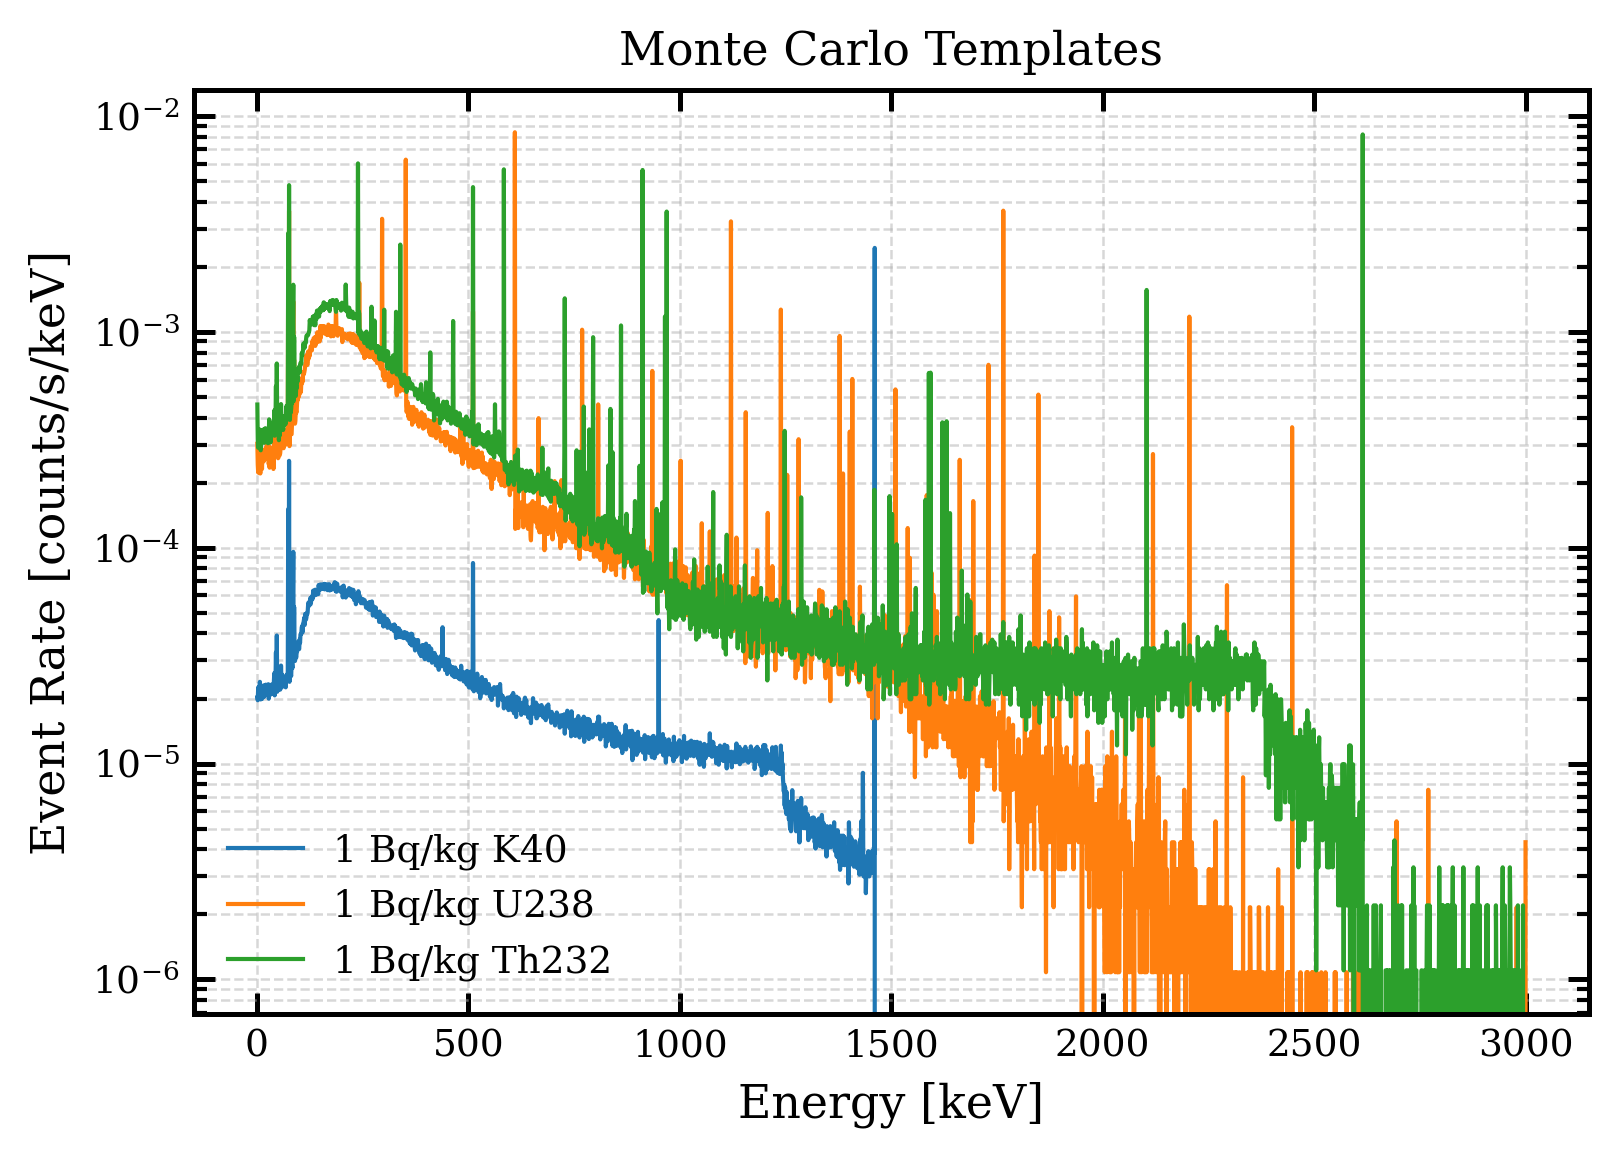

In [27]:
plt.figure()
plt.yscale( 'log' )
plt.xlabel( 'Energy [keV]' )
plt.ylabel( 'Event Rate [counts/s/keV]' )
plt.title(  'Monte Carlo Templates')

for key,val in mc_template.items():
    plt.plot( bins[1:], val, label=f'1 Bq/kg {key}', linewidth=1)

plt.legend()

## Detector Response Matrix

Note that this response matrix must be column-normalized in order to preserve total counts. This is different from preserving the norm of the vector.

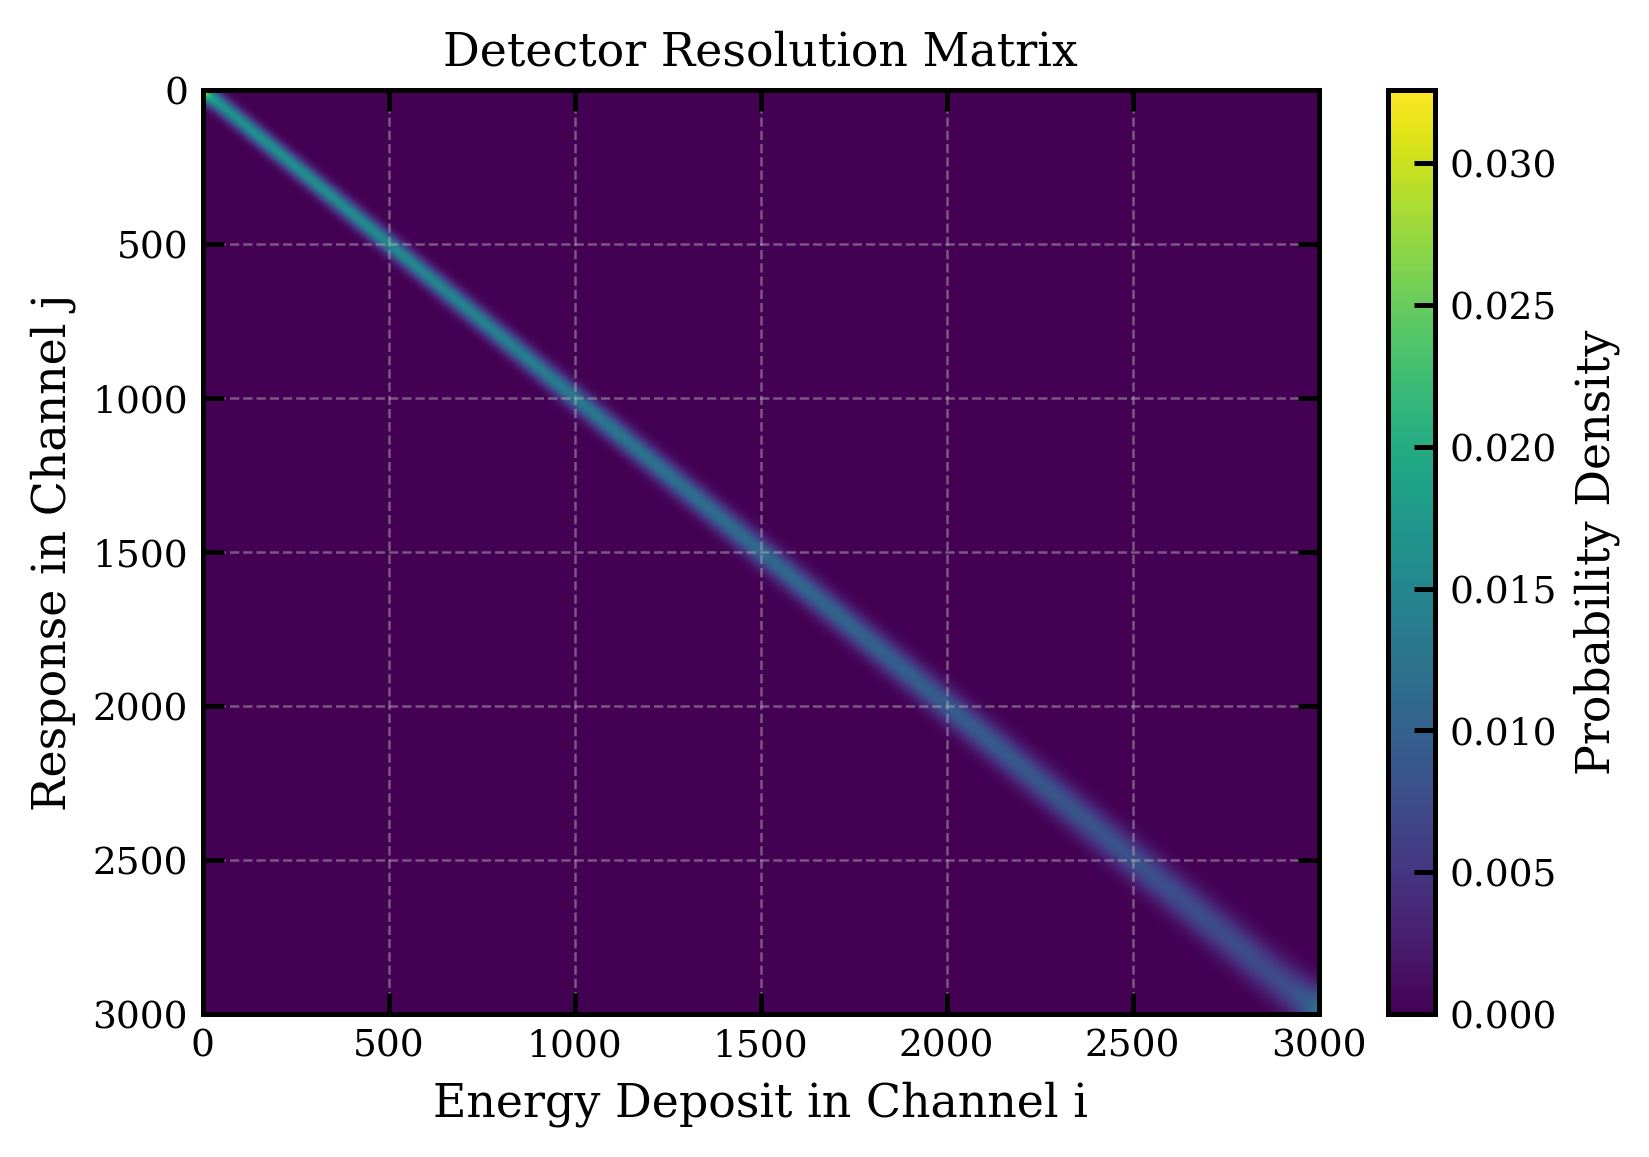

In [28]:
from scipy.stats import norm

a,b,c = calibration_resolution['bottom']

def resolution( E ):
    return np.sqrt( c + b*E + a*E**2 )
    
R = np.zeros( (len(bins[:-1]), len(bins[:-1])) )

for i, E0 in enumerate( (bins[1:]+bins[:-1])/2 ):
    sigma = resolution( E0 )
    R[:,i] = norm.pdf( (bins[1:]+bins[:-1])/2, loc=E0, scale=sigma)
    R[:,i] /= R[:,i].sum()

plt.imshow( R, extent=[bins[0], bins[-1], bins[-1], bins[0]], aspect='auto', cmap='viridis')
plt.xlabel( "Energy Deposit in Channel i")
plt.ylabel( "Response in Channel j")
plt.title( "Detector Resolution Matrix")
plt.colorbar( label="Probability Density")
plt.show()

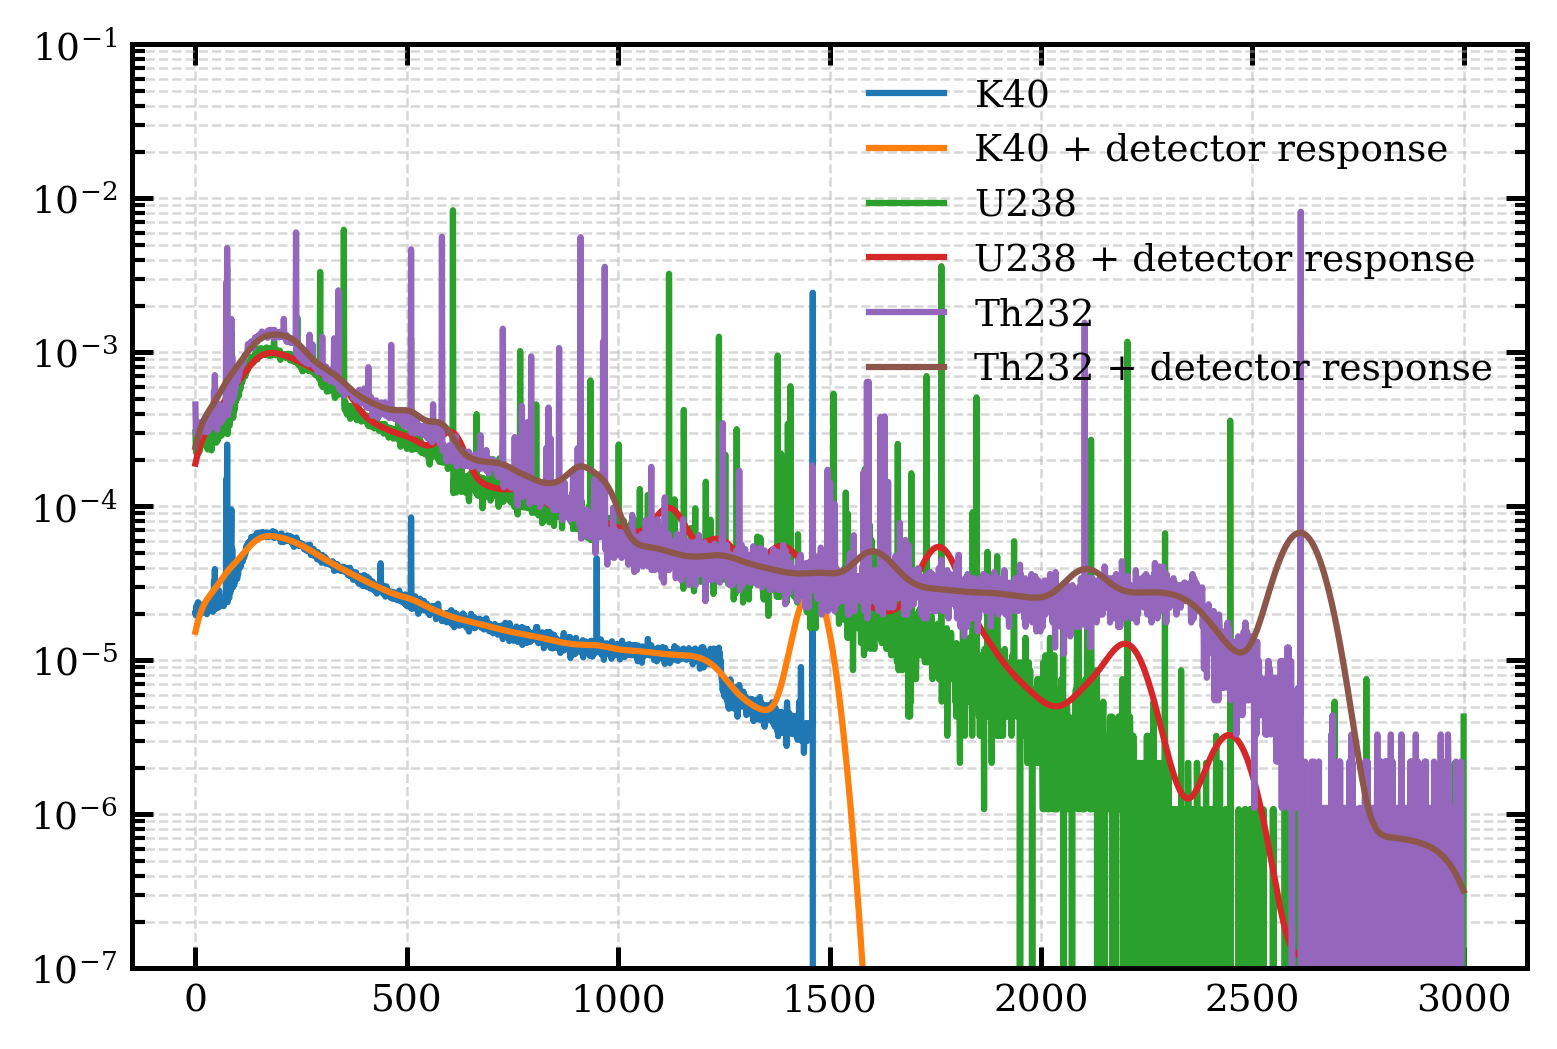

In [29]:
plt.figure()
plt.yscale('log')
plt.ylim([1e-7, 1e-1])

for key,val in mc_template.items():
    plt.plot( bin_centers, val, label=key)
    plt.plot( bin_centers, R @ val, label=key+" + detector response")

plt.legend()

## Formally Construct Fitting Function

In [76]:
lower_threshold = 650 # in keV

def gamma_spectrum( x, act_K40, act_U238, act_Th232, res_a, res_b, res_c, template = mc_template ):
    '''
    x: energy / bin center values in keV
    act_: activities in Bq/kg of each isotopes
    res_a,b,c: 
    '''
    
    def _resolution( E, a, b, c ):
        return np.sqrt( c + b*E + a*E**2 )
    
    R = np.zeros( (len(x), len(x)) )

    for i, E0 in enumerate( x ):
        sigma = _resolution( E0, res_a, res_b, res_c )
        R[:,i] = norm.pdf( x, loc=E0, scale=sigma)
        R[:,i] /= R[:,i].sum()

    return act_K40 * R @ template['K40'] + act_U238 * R @ template['U238'] + act_Th232 * R @ template['Th232']

def gamma_spectrum_cut( x, act_K40, act_U238, act_Th232, res_a, res_b, res_c, template = mc_template, lower_threshold = lower_threshold ):
    return gamma_spectrum( x, act_K40, act_U238, act_Th232, res_a, res_b, res_c, template = mc_template )[lower_threshold:]

## Perform Spectral Fit

Fit parameters are: 657.3922675987585 17.640000000000004 18.510000000000005 0.00025652710846648275 0.04473276795307439 464.04657158339194


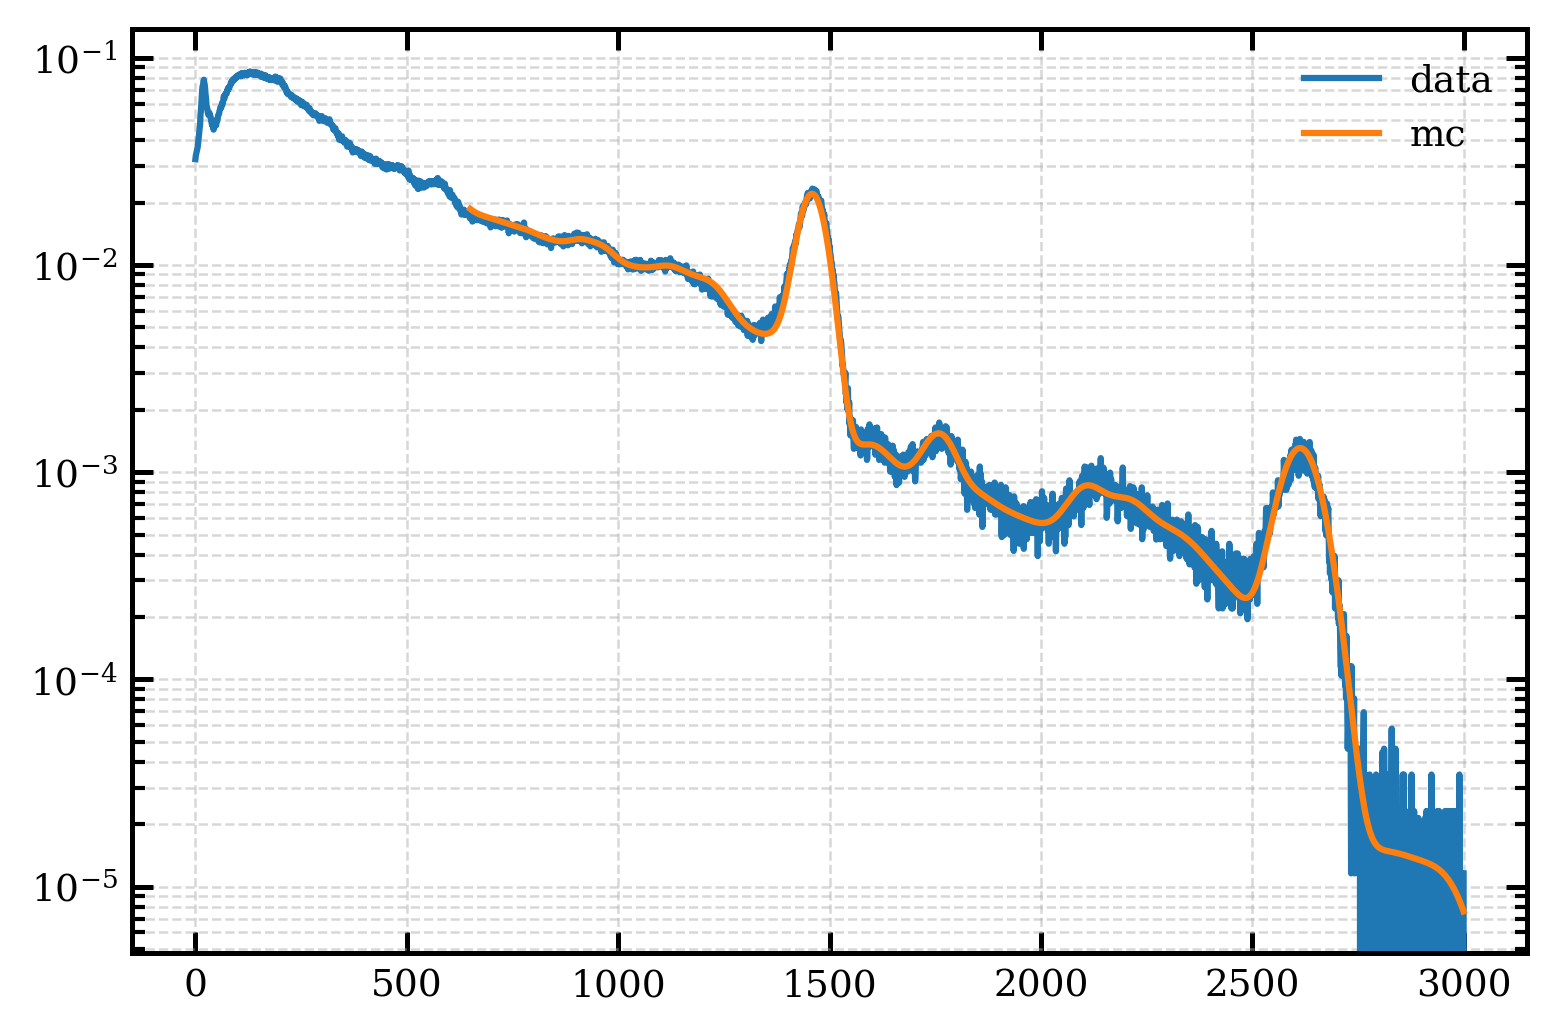

In [77]:
a,b,c = calibration_resolution['bottom']

bounds = ([640, 17.6400, 18.5100, 0.8*a, 0.8*b, 0.8*c],\
          [680, 17.64001, 18.51001, 1.2*a, 1.2*b, 1.2*c])

popt, pcov = curve_fit( gamma_spectrum_cut, bin_center, spectrum['bottom'][lower_threshold:], bounds=bounds )

print( "Fit parameters are:", *popt)

plt.figure()
plt.yscale('log')

plt.plot( bin_center, spectrum['bottom'], label="data")
plt.plot( bin_center[lower_threshold:], gamma_spectrum_cut( bin_center, *popt ), label="mc")

plt.legend()

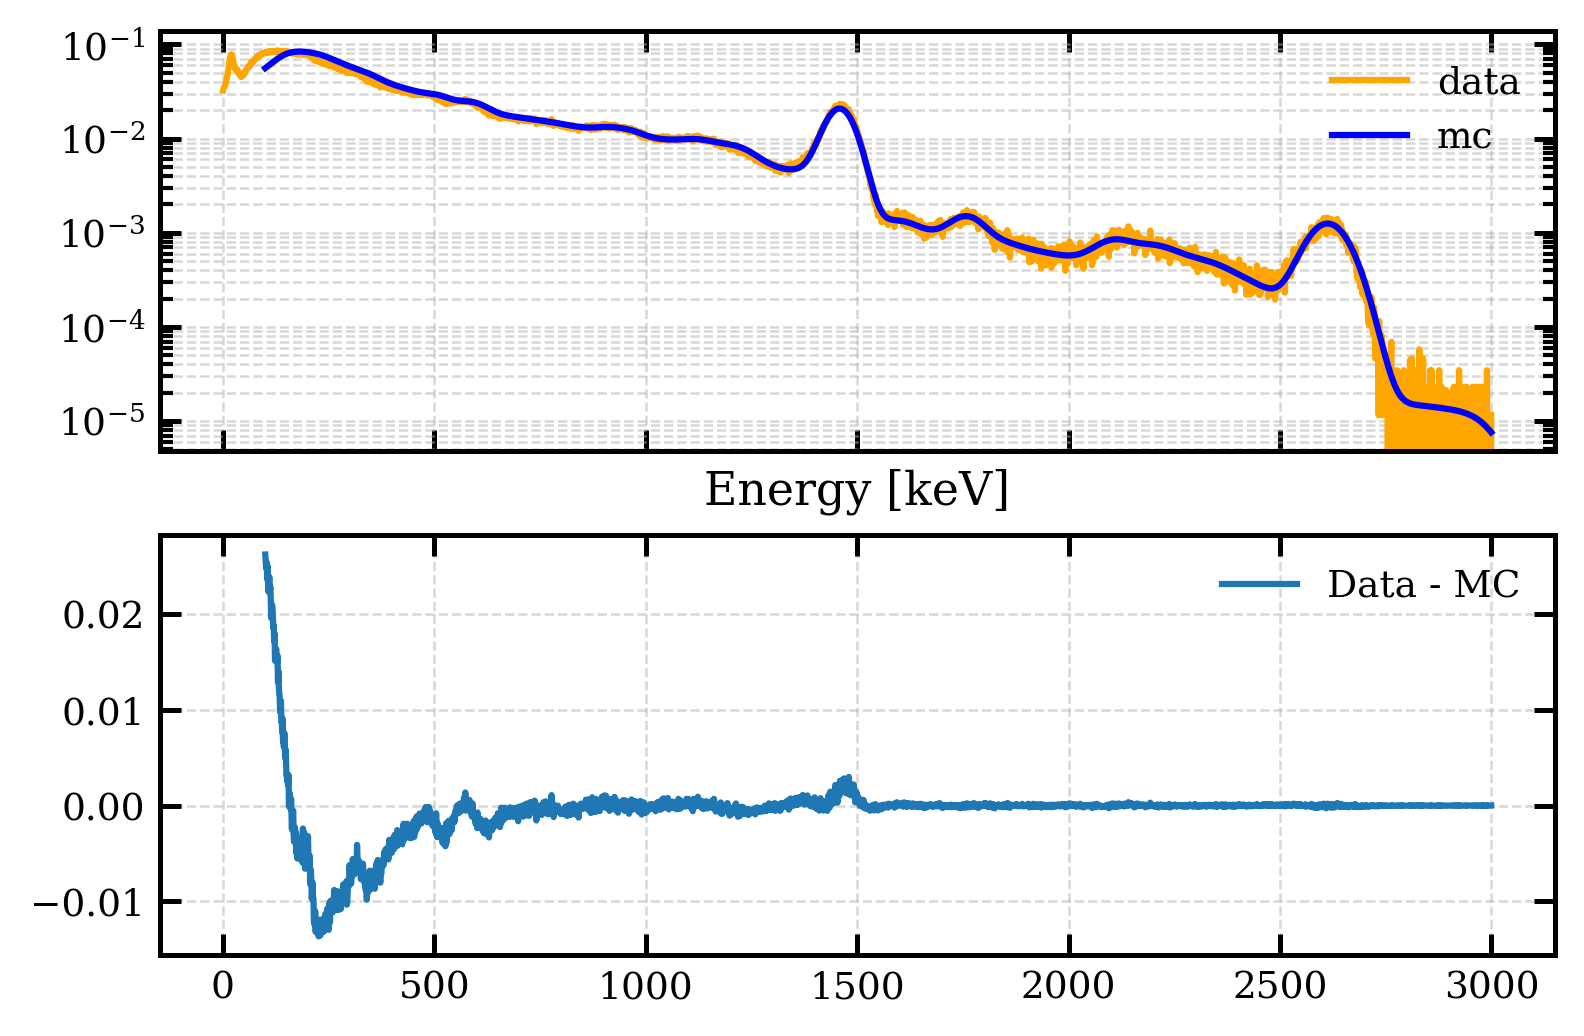

In [86]:
lower_threshold = 100

fig, ax = plt.subplots( 2, 1, sharex=True)
ax[0].set_xlabel( "Energy [keV]")
ax[0].set_yscale('log')

bin_center = (bins[1:] + bins[:-1])/2
ax[0].plot( bin_center, spectrum['bottom'], label="data", linestyle='-', color = 'orange')
ax[0].plot( bin_center[lower_threshold:], \
           gamma_spectrum_cut( bin_center, 657.3922, 17.641376, 18.51058, *calibration_resolution['bottom'], mc_template, lower_threshold ),\
           color = 'blue', label="mc" )
ax[0].legend()

ax[1].plot( bin_center[lower_threshold:], spectrum['bottom'][lower_threshold:] - \
           gamma_spectrum_cut( bin_center, 657.3922, 17.641376, 18.51058, *calibration_resolution['bottom'], mc_template, lower_threshold),\
           label="Data - MC" )
ax[1].legend()